# Phân tích Thị trường Chứng khoán và Dự báo Xu hướng Giá sử dụng PySpark

## Tóm tắt Bài toán
Dự báo **xu hướng giá chứng khoán** (tăng/giảm) cho ngày tiếp theo dựa trên dữ liệu lịch sử từ **2013 đến 2026** sử dụng Machine Learning và PySpark.

**Mục tiêu chính:**
- Phân tích dữ liệu nhiều cổ phiếu (multi-stock)
- Xây dựng đặc trưng (features) hiệu quả bằng Window Functions
- Huấn luyện và so sánh 2 mô hình: Logistic Regression & Random Forest
- Đánh giá hiệu suất theo từng cổ phiếu
- Backtest chiến lược giao dịch dựa trên dự báo
- Tính lợi nhuận giả lập so với Buy & Hold strategy


## PHẦN 1: KHỞI TẠO PYSPARK VÀ IMPORT THƯ VIỆN

Trong phần này, chúng tôi sẽ:
- Import các thư viện cần thiết (PySpark, pandas, matplotlib, scikit-learn)
- Khởi tạo SparkSession cấu hình cho môi trường local
- Thiết lập cấu hình memory phù hợp

In [1]:
# Import thư viện PySpark
from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, DoubleType, LongType
from pyspark.sql.functions import (
    col, to_timestamp, lag, lead, avg, when, count, sum as spark_sum,
    min as spark_min, max as spark_max, lit, greatest,
    abs as spark_abs
)
from pyspark.sql.window import Window
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pathlib import Path
# Import thư viện khác
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Cấu hình matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Đã import tất cả thư viện thành công!")

✓ Đã import tất cả thư viện thành công!


In [2]:
# Khởi tạo SparkSession cho local execution
spark = SparkSession.builder \
    .appName("StockAnalysisPySpark") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Cấu hình Spark
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
spark.sparkContext.setLogLevel("ERROR")

print("✓ SparkSession đã khởi tạo thành công!")
print(f"  - Spark Version: {spark.version}")
print(f"  - Python Version: {pd.__version__}")
print(f"  - NumPy Version: {np.__version__}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 12:48:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✓ SparkSession đã khởi tạo thành công!
  - Spark Version: 4.1.1
  - Python Version: 3.0.2
  - NumPy Version: 2.4.4


## PHẦN 2: NẠP VÀ KHÁM PHÁ DỮ LIỆU

Công việc trong phần này:
- Đọc tất cả file CSV từ thư mục `/home/admin/Documents/VSC/data/csv`
- Thêm cột `ticker` từ tên file
- Hiển thị schema, kiểu dữ liệu, và dòng dữ liệu mẫu
- Hiển thị thống kê cơ bản của các cột giá (open, high, low, close, volume)
- Liệt kê các cổ phiếu duy nhất (unique tickers)

In [3]:
# Đường dẫn thư mục dữ liệu (tự động theo thư mục hiện tại)
data_dir = str(Path("csv").resolve())
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))

print(f"📂 Tìm thấy {len(csv_files)} file CSV")
print(f"📍 Thư mục: {data_dir}\n")

# Đọc từng file và thêm cột ticker
dataframes = []
for csv_file in csv_files:
    ticker = os.path.basename(csv_file).replace('.csv', '')
    df_temp = spark.read.csv(csv_file, header=True, inferSchema=True)
    df_temp = df_temp.withColumn("ticker", lit(ticker))
    dataframes.append(df_temp)
    print(f"✓ Loaded: {ticker:6s} - {df_temp.count():,d} rows")

# Union tất cả dataframes
df_raw = dataframes[0]
for df_temp in dataframes[1:]:
    df_raw = df_raw.union(df_temp)

print(f"\n✓ Tổng dữ liệu: {df_raw.count():,d} rows từ {len(dataframes)} cổ phiếu")

📂 Tìm thấy 65 file CSV
📍 Thư mục: /home/admin/Documents/VSC/data/csv

✓ Loaded: XOM    - 3,315 rows
✓ Loaded: SSI    - 3,182 rows
✓ Loaded: NLG    - 3,182 rows
✓ Loaded: BCM    - 2,004 rows
✓ Loaded: NVDA   - 3,315 rows
✓ Loaded: COST   - 3,315 rows
✓ Loaded: MBB    - 3,182 rows
✓ Loaded: F      - 3,315 rows
✓ Loaded: JPM    - 3,315 rows
✓ Loaded: PLX    - 2,220 rows
✓ Loaded: SAB    - 2,311 rows
✓ Loaded: CVX    - 3,315 rows
✓ Loaded: AMD    - 3,315 rows
✓ Loaded: MA     - 3,315 rows
✓ Loaded: VPB    - 2,138 rows
✓ Loaded: VIX    - 3,315 rows
✓ Loaded: AAPL   - 3,315 rows
✓ Loaded: VCB    - 3,182 rows
✓ Loaded: MSFT   - 3,315 rows
✓ Loaded: BAC    - 3,315 rows
✓ Loaded: POW    - 1,993 rows
✓ Loaded: VZ     - 3,315 rows
✓ Loaded: MWG    - 2,912 rows
✓ Loaded: TSLA   - 3,315 rows
✓ Loaded: ACB    - 3,182 rows
✓ Loaded: META   - 3,315 rows
✓ Loaded: REE    - 3,182 rows
✓ Loaded: BA     - 3,315 rows
✓ Loaded: VJC    - 2,257 rows
✓ Loaded: LCID   - 1,373 rows
✓ Loaded: VNINDEX - 3,301 rows

In [4]:
# Hiển thị schema và thông tin cơ bản
print("=" * 80)
print("SCHEMA CỦA DỮ LIỆU")
print("=" * 80)
df_raw.printSchema()

print("\n" + "=" * 80)
print("10 DÒNG DỮ LIỆU MẪU ĐẦU TIÊN")
print("=" * 80)
df_raw.show(10, truncate=False)

print("\n" + "=" * 80)
print("THỐNG KÊ CỌC BẢN")
print("=" * 80)
df_raw.describe(['open', 'high', 'low', 'close', 'volume']).show()

print("\n" + "=" * 80)
print("DANH SÁCH CỔ PHIẾU")
print("=" * 80)
tickers = df_raw.select("ticker").distinct().collect()
ticker_list = sorted([row.ticker for row in tickers])
print(f"Tổng {len(ticker_list)} cổ phiếu: {', '.join(ticker_list)}")

SCHEMA CỦA DỮ LIỆU
root
 |-- time: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: long (nullable = true)
 |-- ticker: string (nullable = false)


10 DÒNG DỮ LIỆU MẪU ĐẦU TIÊN
+----------+------------------+------------------+------------------+------------------+--------+------+
|time      |open              |high              |low               |close             |volume  |ticker|
+----------+------------------+------------------+------------------+------------------+--------+------+
|2013-01-02|51.15641340001558 |51.69833707671643 |50.83591922990997 |51.692508697509766|16143700|XOM   |
|2013-01-03|51.546827163511594|51.79739410496032 |51.37201580983254 |51.599273681640625|13268200|XOM   |
|2013-01-04|51.570151901795555|51.913950780513325|51.494400736760745|51.838199615478516|11427900|XOM   |
|2013-01-07|51.45941317035356 |51.564301748441046|51.028206547

+-------+------------------+------------------+------------------+------------------+-------------------+
|summary|              open|              high|               low|             close|             volume|
+-------+------------------+------------------+------------------+------------------+-------------------+
|  count|            196816|            196816|            196816|            196816|             196816|
|   mean|129.18701516204695|130.34584707172837|127.99219097052497|129.20728907465477|9.842966735425474E7|
| stddev| 478.0885514596267| 480.6782528525168|475.30003803298104| 478.1826404862831| 5.37941567627402E8|
|    min|0.2758871841480986|0.2800393674811535|0.2747338435461983|0.2763485610485077|                  0|
|    max|            7002.0|  7002.27978515625|   6963.4599609375|  6978.60009765625|         9976520000|
+-------+------------------+------------------+------------------+------------------+-------------------+


DANH SÁCH CỔ PHIẾU


Tổng 65 cổ phiếu: AAPL, ACB, AMD, AMZN, BA, BAC, BCM, BID, BVH, COST, CTG, CVX, DHG, DIS, F, FPT, GAS, GM, GMD, GOOGL, GS, HDB, HPG, HSG, INTC, JPM, KDH, LCID, LLY, MA, MBB, META, MSFT, MSN, MWG, NFLX, NKG, NLG, NVDA, PLX, PNJ, POW, REE, RIVN, SAB, SP500, SSI, STB, TCB, TSLA, UNH, V, VCB, VHM, VIC, VIX, VJC, VNINDEX, VNM, VPB, VRE, VZ, WFC, WMT, XOM


## PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU (PYSPARK)

Công việc chính:
- **Convert kiểu dữ liệu**: Chuyển cột `time` → `timestamp`, các cột giá/khối lượng → `double`/`long`
- **Loại bỏ bản ghi trùng** và dòng lỗi (giá <= 0)
- **Xử lý missing values**: Drop hoặc fill tùy theo tính chất dữ liệu
- **Sort dữ liệu**: Theo ticker và date để chuẩn bị cho window functions
- **Kiểm tra chất lượng**: Xác minh dữ liệu sau xử lý

In [5]:
# Step 1: Convert kiểu dữ liệu
print("Step 1: Convert kiểu dữ liệu...")
df_processed = df_raw \
    .withColumn("time", to_timestamp(col("time"), "yyyy-MM-dd")) \
    .withColumn("open", col("open").cast(DoubleType())) \
    .withColumn("high", col("high").cast(DoubleType())) \
    .withColumn("low", col("low").cast(DoubleType())) \
    .withColumn("close", col("close").cast(DoubleType())) \
    .withColumn("volume", col("volume").cast(LongType())) \
    .withColumn("ticker", col("ticker").cast(StringType()))

# Step 2: Loại bỏ null values
print("Step 2: Loại bỏ null values...")
null_count_before = df_processed.count()
df_processed = df_processed.dropna()
null_count_after = df_processed.count()
print(f"  - Loại bỏ {null_count_before - null_count_after:,d} dòng null")

# Step 3: Loại bỏ dòng lỗi (giá <= 0)
print("Step 3: Loại bỏ dòng lỗi (giá <= 0)...")
invalid_count = df_processed.filter((col("close") <= 0) | (col("volume") <= 0)).count()
df_processed = df_processed.filter((col("close") > 0) & (col("volume") > 0))
print(f"  - Loại bỏ {invalid_count:,d} dòng lỗi")

# Step 4: Loại bỏ bản ghi trùng
print("Step 4: Loại bỏ bản ghi trùng...")
df_processed = df_processed.dropDuplicates(['time', 'ticker'])

# Step 5: Sort theo ticker và date
print("Step 5: Sort theo ticker và date...")
df_processed = df_processed.sort(['ticker', 'time'])

print(f"\n✓ Dữ liệu sau xử lý: {df_processed.count():,d} rows")
print("\n10 dòng đầu sau xử lý:")
df_processed.show(10)

Step 1: Convert kiểu dữ liệu...
Step 2: Loại bỏ null values...


  - Loại bỏ 0 dòng null
Step 3: Loại bỏ dòng lỗi (giá <= 0)...


  - Loại bỏ 4,561 dòng lỗi
Step 4: Loại bỏ bản ghi trùng...
Step 5: Sort theo ticker và date...



✓ Dữ liệu sau xử lý: 192,255 rows

10 dòng đầu sau xử lý:


+-------------------+------------------+------------------+------------------+------------------+---------+------+
|               time|              open|              high|               low|             close|   volume|ticker|
+-------------------+------------------+------------------+------------------+------------------+---------+------+
|2013-01-02 00:00:00|16.726062542519166|16.761700040600363|16.357910009727583|16.581398010253906|560518000|  AAPL|
|2013-01-03 00:00:00| 16.54666598301802|16.600726265962198|16.338881397575303|16.372102737426758|352965200|  AAPL|
|2013-01-04 00:00:00|16.217179615848526|16.267314076991514|15.880736945619178|15.916072845458984|594333600|  AAPL|
|2013-01-07 00:00:00|15.765069599331184|15.985538370818867|15.559701008828565|15.822452545166016|484156400|  AAPL|
|2013-01-08 00:00:00|15.982814573333348|16.063754222621842|15.742413395470727|15.865029335021973|458707200|  AAPL|
|2013-01-09 00:00:00|15.780160698221348|15.855966401880957|15.583550390363834|15

## PHẦN 4: PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)

Mục đích:
- Chuyển Spark DataFrame sang pandas để vẽ biểu đồ
- Phân tích xu hướng giá theo thời gian cho các cổ phiếu đã chọn
- So sánh biến động giá giữa các cổ phiếu
- Phân tích mối quan hệ volume và giá
- Hiểu rõ đặc điểm dữ liệu trước khi xây dựng model

Chuyển dữ liệu Spark sang Pandas...


✓ Chuyển xong: 192,255 rows
Chọn 5 cổ phiếu đại diện: ['AAPL', 'ACB', 'AMD', 'AMZN', 'BA']


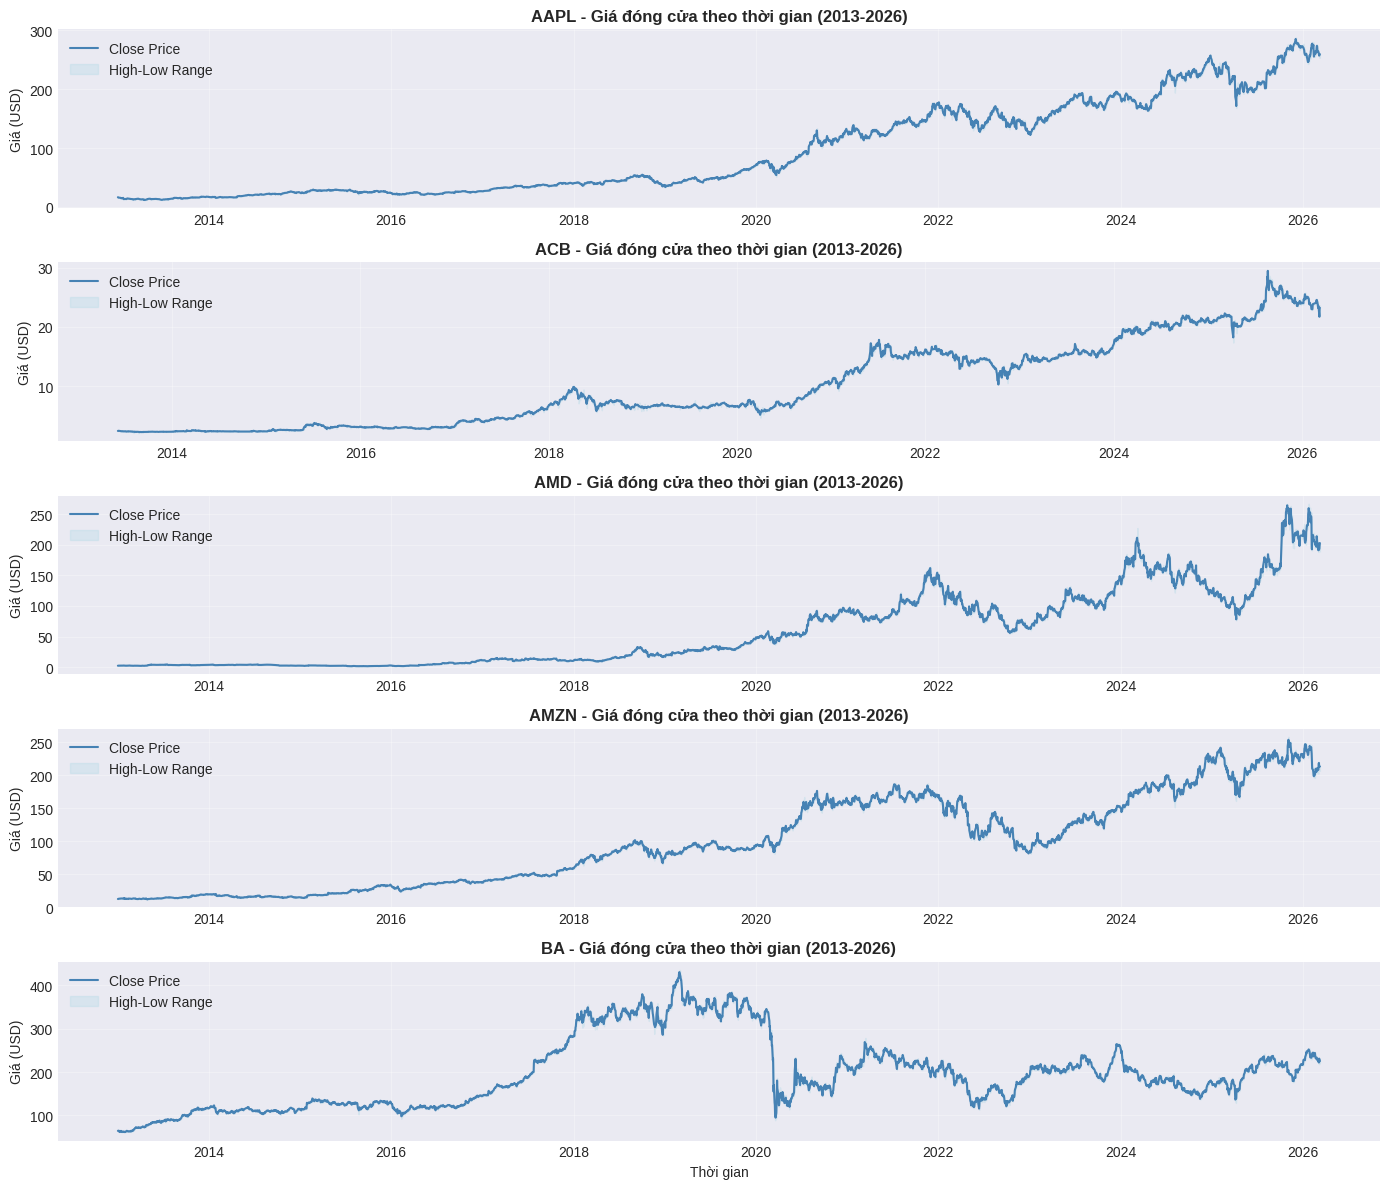

✓ Biểu đồ vẽ xong!


In [6]:
# Chuyển dữ liệu Spark sang Pandas để vẽ biểu đồ
print("Chuyển dữ liệu Spark sang Pandas...")
df_pandas = df_processed.toPandas()
df_pandas['time'] = pd.to_datetime(df_pandas['time'])

print(f"✓ Chuyển xong: {len(df_pandas):,d} rows")

# Chọn một vài cổ phiếu đại diện để vẽ biểu đồ
selected_tickers = df_pandas['ticker'].unique()[:5]
print(f"Chọn {len(selected_tickers)} cổ phiếu đại diện: {list(selected_tickers)}")

# Vẽ biểu đồ giá theo thời gian
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 12))
if len(selected_tickers) == 1:
    axes = [axes]

for idx, ticker in enumerate(selected_tickers):
    data = df_pandas[df_pandas['ticker'] == ticker].sort_values('time')
    axes[idx].plot(data['time'], data['close'], linewidth=1.5, color='steelblue', label='Close Price')
    axes[idx].fill_between(data['time'], data['low'], data['high'], alpha=0.3, color='lightblue', label='High-Low Range')
    axes[idx].set_title(f'{ticker} - Giá đóng cửa theo thời gian (2013-2026)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Giá (USD)', fontsize=10)
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.xlabel('Thời gian', fontsize=10)
plt.tight_layout()
plt.show()

print("✓ Biểu đồ vẽ xong!")

## PHẦN 5: FEATURE ENGINEERING

Sử dụng **PySpark Window Functions** (phân chia theo ticker, sắp xếp theo time) để tạo các đặc trưng dự báo.

### Vấn đề và cách xử lý

| Vấn đề | Giải pháp |
|--------|-----------|
| **Nhiễu từ các phiên biến động nhỏ** – các ngày tăng/giảm < 1% không mang tín hiệu rõ ràng | Dùng **label có ngưỡng**: chỉ coi là tăng/giảm khi `\|future_return\| > 1.0%` |
| **OHLCV thô không đủ thông tin thị trường** | Bổ sung 34 features kỹ thuật (RSI, MACD, BB, ATR, ADX, CCI, ...) |

### Nhóm đặc trưng (34 features tổng)

1. **Return & Lag**: `daily_return`, `lag1–3_close`, `lag1_volume`, `prev_high/low`, `lag5/10_return`
2. **Moving Average**: MA5, MA10, MA20, MA50, `price_vs_ma`
3. **Momentum**: RSI(7), RSI(14), Stochastic %K, Williams %R, CCI(14), Momentum 5/10
4. **Trend**: MACD, MACD Signal (SMA proxy trong Spark – EMA thực ở pipeline DL), ADX(14)
5. **Volatility**: ATR(14), ATR ratio, Bollinger upper/lower/bandwidth/%B, Volatility 5/20d
6. **Volume**: Volume change, Volume MA ratio, OBV signal
7. **Range**: High-low range, Close-open return

Cách này giúp giảm nhiễu cho bài toán tăng/giảm và cung cấp đủ ngữ cảnh thị trường để model tổng quát tốt hơn.

In [7]:
# Định nghĩa Window Function: Phân chia theo ticker, sắp xếp theo time
windowSpec = Window.partitionBy('ticker').orderBy('time')

print("Bắt đầu Feature Engineering sử dụng Window Functions...")

# Feature 1: Lag(Close)
df_features = df_processed \
    .withColumn('lag1_close', lag('close', 1).over(windowSpec)) \
    .withColumn('lag2_close', lag('close', 2).over(windowSpec)) \
    .withColumn('lag3_close', lag('close', 3).over(windowSpec)) \
    .withColumn('lag1_high',  lag('high',  1).over(windowSpec)) \
    .withColumn('lag1_low',   lag('low',   1).over(windowSpec))

# Feature 2: Lead(Close) – dùng để tạo label
df_features = df_features \
    .withColumn('next_close', lead('close', 1).over(windowSpec))

# Feature 3: Future Return
df_features = df_features \
    .withColumn('future_return', (col('next_close') - col('close')) / col('close'))

# Feature 4: Daily Return
df_features = df_features \
    .withColumn('daily_return', (col('close') - col('lag1_close')) / col('lag1_close'))

# Feature 5: Lag Return
df_features = df_features \
    .withColumn('lag1_return',  lag('daily_return',  1).over(windowSpec)) \
    .withColumn('lag5_return',  lag('daily_return',  5).over(windowSpec)) \
    .withColumn('lag10_return', lag('daily_return', 10).over(windowSpec))

# Feature 6-7: MA5 / MA10
df_features = df_features \
    .withColumn('ma5',  avg('close').over(windowSpec.rowsBetween(-4,  0))) \
    .withColumn('ma10', avg('close').over(windowSpec.rowsBetween(-9,  0)))

# ── CẢI TIẾN 2: Thêm MA20 / MA50 ──
df_features = df_features \
    .withColumn('ma20', avg('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('ma50', avg('close').over(windowSpec.rowsBetween(-49, 0)))

# ── CẢI TIẾN 2b: Price vs MA (momentum signal) ──
df_features = df_features \
    .withColumn('price_vs_ma5',  (col('close') - col('ma5'))  / col('ma5'))  \
    .withColumn('price_vs_ma20', (col('close') - col('ma20')) / col('ma20'))

# Feature 8: Rolling volatility 5-day
from pyspark.sql.functions import stddev_pop
df_features = df_features \
    .withColumn('rolling_volatility_5', stddev_pop('daily_return').over(windowSpec.rowsBetween(-4, 0)))

# Feature 9: RSI(14)
rsi_window = windowSpec.rowsBetween(-14, 0)
df_features = df_features \
    .withColumn('price_change', col('close') - col('lag1_close')) \
    .withColumn('gain', when(col('price_change') > 0, col('price_change')).otherwise(0.0)) \
    .withColumn('loss', when(col('price_change') < 0, -col('price_change')).otherwise(0.0)) \
    .withColumn('avg_gain_14', avg('gain').over(rsi_window)) \
    .withColumn('avg_loss_14', avg('loss').over(rsi_window)) \
    .withColumn('rs_14', when(col('avg_loss_14') == 0, None).otherwise(col('avg_gain_14') / col('avg_loss_14'))) \
    .withColumn('rsi_14', when(col('avg_loss_14') == 0, 100.0).otherwise(100 - (100 / (1 + col('rs_14')))))

# Feature 10: MACD (SMA proxy trong PySpark – PySpark không hỗ trợ ewm() nội sinh;
#             EMA thực được tính lại trong pipeline học sâu – Phần 11G)
df_features = df_features \
    .withColumn('ema12_proxy', avg('close').over(windowSpec.rowsBetween(-11, 0))) \
    .withColumn('ema26_proxy', avg('close').over(windowSpec.rowsBetween(-25, 0))) \
    .withColumn('macd', col('ema12_proxy') - col('ema26_proxy')) \
    .withColumn('macd_signal', avg('macd').over(windowSpec.rowsBetween(-8, 0)))

# Feature 11: Bollinger Bands (20-day)
df_features = df_features \
    .withColumn('bb_mid', avg('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('bb_std', stddev_pop('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('bb_upper', col('bb_mid') + (2 * col('bb_std'))) \
    .withColumn('bb_lower', col('bb_mid') - (2 * col('bb_std'))) \
    .withColumn('bb_bandwidth', when(col('bb_mid') != 0, (col('bb_upper') - col('bb_lower')) / col('bb_mid')).otherwise(None))

# Feature 12: Volume-based
df_features = df_features \
    .withColumn('lag1_volume', lag('volume', 1).over(windowSpec)) \
    .withColumn('volume_change', when(col('lag1_volume').isNull() | (col('lag1_volume') == 0), None)
                .otherwise((col('volume') - col('lag1_volume')) / col('lag1_volume'))) \
    .withColumn('high_low_range', when(col('close') != 0, (col('high') - col('low')) / col('close')).otherwise(None)) \
    .withColumn('close_open_return', when(col('open') != 0, (col('close') - col('open')) / col('open')).otherwise(None))

# ── CẢI TIẾN 3: Stochastic %K(14) ──
stoch_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('low14',  spark_min('low').over(stoch_w)) \
    .withColumn('high14', spark_max('high').over(stoch_w)) \
    .withColumn('stoch_k',
        when(col('high14') == col('low14'), 50.0)
        .otherwise((col('close') - col('low14')) / (col('high14') - col('low14')) * 100))

# ── Williams %R(14) – Stochastic đảo chiều ──
df_features = df_features \
    .withColumn('williams_r',
        when(col('high14') == col('low14'), -50.0)
        .otherwise((col('high14') - col('close')) / (col('high14') - col('low14')) * (-100)))

# ── CCI(14) – Commodity Channel Index (xấp xỉ bằng stddev thay vì MAD) ──
df_features = df_features \
    .withColumn('tp', (col('high') + col('low') + col('close')) / 3.0)
cci_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('tp_ma14',   avg('tp').over(cci_w)) \
    .withColumn('tp_std14',  stddev_pop('tp').over(cci_w)) \
    .withColumn('cci14',
        when(col('tp_std14') == 0, 0.0)
        .otherwise((col('tp') - col('tp_ma14')) / (0.015 * col('tp_std14'))))

# ── ADX(14) – Average Directional Index (đo độ mạnh xu hướng) ──
df_features = df_features \
    .withColumn('plus_dm',
        when((col('high') - col('lag1_high')) > (col('lag1_low') - col('low')),
             greatest(col('high') - col('lag1_high'), lit(0.0)))
        .otherwise(lit(0.0))) \
    .withColumn('minus_dm',
        when((col('lag1_low') - col('low')) > (col('high') - col('lag1_high')),
             greatest(col('lag1_low') - col('low'), lit(0.0)))
        .otherwise(lit(0.0))) \
    .withColumn('true_range', greatest(
        col('high') - col('low'),
        spark_abs(col('high') - col('lag1_close')),
        spark_abs(col('low')  - col('lag1_close'))))
adx_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('smooth_tr',   avg('true_range').over(adx_w)) \
    .withColumn('plus_di14',   when(col('smooth_tr') > 0, 100 * avg('plus_dm').over(adx_w)  / col('smooth_tr')).otherwise(0.0)) \
    .withColumn('minus_di14',  when(col('smooth_tr') > 0, 100 * avg('minus_dm').over(adx_w) / col('smooth_tr')).otherwise(0.0)) \
    .withColumn('adx14',
        when((col('plus_di14') + col('minus_di14')) == 0, 0.0)
        .otherwise(spark_abs(col('plus_di14') - col('minus_di14')) / (col('plus_di14') + col('minus_di14')) * 100))

# ── CẢI TIẾN 4: ATR(14) – Average True Range ──
df_features = df_features \
    .withColumn('atr14', avg(col('high') - col('low')).over(windowSpec.rowsBetween(-13, 0)))

# ── CẢI TIẾN 5: OBV direction signal (proxy – trung bình chiều giá 5 ngày, xấp xỉ tín hiệu OBV) ──
df_features = df_features \
    .withColumn('price_dir',
        when(col('close') > col('lag1_close'), 1.0)
        .when(col('close') < col('lag1_close'), -1.0)
        .otherwise(0.0)) \
    .withColumn('obv_signal', avg('price_dir').over(windowSpec.rowsBetween(-4, 0)))


# ── CẢI TIẾN 6: RSI(7) và RSI(21) – đa khung thời gian ──
# Tái dùng cột gain/loss đã tính từ RSI(14)
df_features = df_features \
    .withColumn('avg_gain_7',  avg('gain').over(windowSpec.rowsBetween(-7,  0))) \
    .withColumn('avg_loss_7',  avg('loss').over(windowSpec.rowsBetween(-7,  0))) \
    .withColumn('rsi_7',
        when(col('avg_loss_7') == 0, 100.0)
        .otherwise(100 - (100 / (1 + col('avg_gain_7') / col('avg_loss_7'))))) \
    .withColumn('avg_gain_21', avg('gain').over(windowSpec.rowsBetween(-21, 0))) \
    .withColumn('avg_loss_21', avg('loss').over(windowSpec.rowsBetween(-21, 0))) \
    .withColumn('rsi_21',
        when(col('avg_loss_21') == 0, 100.0)
        .otherwise(100 - (100 / (1 + col('avg_gain_21') / col('avg_loss_21')))))

# ── CẢI TIẾN 7: Volatility đa khung thời gian (10-day, 20-day) ──
df_features = df_features \
    .withColumn('rolling_volatility_10', stddev_pop('daily_return').over(windowSpec.rowsBetween(-9,  0))) \
    .withColumn('rolling_volatility_20', stddev_pop('daily_return').over(windowSpec.rowsBetween(-19, 0)))

# ── CẢI TIẾN 8: Volume MA Ratio – volume so với trung bình 20 phiên ──
df_features = df_features \
    .withColumn('avg_volume_20', avg('volume').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('volume_ma_ratio',
        when(col('avg_volume_20') == 0, None)
        .otherwise(col('volume') / col('avg_volume_20')))

# ── CẢI TIẾN 9: Momentum 5-day và 10-day ──
df_features = df_features \
    .withColumn('lag5_close',  lag('close', 5).over(windowSpec)) \
    .withColumn('lag10_close', lag('close', 10).over(windowSpec)) \
    .withColumn('momentum_5',
        when(col('lag5_close')  != 0, (col('close') - col('lag5_close'))  / col('lag5_close')).otherwise(None)) \
    .withColumn('momentum_10',
        when(col('lag10_close') != 0, (col('close') - col('lag10_close')) / col('lag10_close')).otherwise(None))

# ── CẢI TIẾN 10: Price vs MA50, MACD Histogram, Bollinger %B, ATR Ratio ──
df_features = df_features \
    .withColumn('price_vs_ma50',
        when(col('ma50') != 0, (col('close') - col('ma50')) / col('ma50')).otherwise(None)) \
    .withColumn('macd_hist', col('macd') - col('macd_signal')) \
    .withColumn('bb_pct_b',
        when((col('bb_upper') - col('bb_lower')) != 0,
             (col('close') - col('bb_lower')) / (col('bb_upper') - col('bb_lower'))).otherwise(None)) \
    .withColumn('atr_ratio',
        when(col('close') != 0, col('atr14') / col('close')).otherwise(None))

# ── CẢI TIẾN 11: Lag Returns 2 và 3 ──
df_features = df_features \
    .withColumn('lag2_return', lag('daily_return', 2).over(windowSpec)) \
    .withColumn('lag3_return', lag('daily_return', 3).over(windowSpec))

# ── FEATURES ĐẶC THÙ THỊ TRƯỜNG VN ─────────────────────────────────────────
vol_w = windowSpec.rowsBetween(-9, 0)

# 1. limit_hit_rate: tần suất chạm biên độ ±7% (20 phiên)
df_features = df_features \
    .withColumn('near_limit',
        when(spark_abs(col('daily_return')) >= 0.068, 1.0).otherwise(0.0)) \
    .withColumn('limit_hit_rate',
        avg('near_limit').over(windowSpec.rowsBetween(-19, 0)))

# 2. zero_change_rate: tần suất giá không đổi (10 phiên)
df_features = df_features \
    .withColumn('no_change',
        when(col('daily_return') == 0.0, 1.0).otherwise(0.0)) \
    .withColumn('zero_change_rate',
        avg('no_change').over(windowSpec.rowsBetween(-9, 0)))

# 3. vol_consistency: std/mean khối lượng (10 phiên) – bất ổn thanh khoản
df_features = df_features \
    .withColumn('vol_std10',  stddev_pop('volume').over(vol_w)) \
    .withColumn('vol_mean10', avg('volume').over(vol_w)) \
    .withColumn('vol_consistency',
        when(col('vol_mean10') > 0, col('vol_std10') / col('vol_mean10')).otherwise(None))

# 4. intraday_pos: vị trí close trong dải high-low (0=đáy, 1=trần)
df_features = df_features \
    .withColumn('intraday_pos',
        when((col('high') - col('low')) > 0,
             (col('close') - col('low')) / (col('high') - col('low'))
        ).otherwise(0.5))

# 5. ato_gap: gap giá ATO mở cửa so với close hôm trước
df_features = df_features \
    .withColumn('ato_gap',
        when(col('lag1_close') != 0,
             (col('open') - col('lag1_close')) / col('lag1_close')
        ).otherwise(None))


# ── Cải tiến 1: 3-day forward return làm label (ít noise hơn next-day) ────
from pyspark.sql.functions import create_map, to_date
df_features = df_features     .withColumn('next_close_3d', lead('close', 3).over(windowSpec))     .withColumn('future_return_3d',
        when(col('close') != 0,
             (col('next_close_3d') - col('close')) / col('close')
        ).otherwise(None))

# ── Cải tiến 2: Sector encoding ─────────────────────────────────────────────
SECTOR_MAP = {
    # VN banks (0)
    'ACB': 0, 'BID': 0, 'CTG': 0, 'MBB': 0, 'TCB': 0, 'VCB': 0, 'VPB': 0,
    'STB': 0, 'HDB': 0,
    # VN securities (1)
    'SSI': 1,
    # VN steel & materials (2)
    'HPG': 2, 'HSG': 2, 'NKG': 2,
    # VN real estate (3)
    'KDH': 3, 'NLG': 3, 'VHM': 3, 'VIC': 3, 'VRE': 3, 'BCM': 3,
    # VN consumer & food (4)
    'MSN': 4, 'SAB': 4, 'VNM': 4, 'PNJ': 4, 'MWG': 4,
    # VN tech (5)
    'FPT': 5,
    # US mega-cap tech & semi (6)
    'AAPL': 6, 'MSFT': 6, 'GOOGL': 6, 'META': 6, 'NVDA': 6,
    'NFLX': 6, 'AMD': 6, 'INTC': 6,
    # US auto / EV (7)
    'TSLA': 7, 'F': 7, 'GM': 7,
    # US banks & finance (8)
    'JPM': 8, 'BAC': 8, 'WFC': 8, 'GS': 8,
    # US retail & consumer (9)
    'AMZN': 9, 'DIS': 9, 'COST': 9, 'WMT': 9,
    # US energy (10)
    'XOM': 10, 'CVX': 10,
    # US healthcare (11)
    'UNH': 11, 'LLY': 11,
    # US payments & fintech (12)
    'V': 12, 'MA': 12,
    # US aerospace & telecom (13)
    'BA': 13, 'VZ': 13,
    # VN energy & utilities (14)
    'GAS': 14, 'PLX': 14, 'POW': 14, 'REE': 14,
    # VN aviation & logistics (15)
    'VJC': 15, 'GMD': 15,
    # VN pharma & insurance (16)
    'DHG': 16, 'BVH': 16,
}
sector_expr = create_map(
    *[item for pair in [(lit(k), lit(float(v))) for k, v in SECTOR_MAP.items()] for item in pair]
)
df_features = df_features.withColumn('sector_idx', sector_expr[col('ticker')])

# ── Cải tiến 3: VN-Index context features ───────────────────────────────────
vnindex_path = str(Path("csv/VNINDEX.csv").resolve())
df_vni = spark.read.option("header", True).option("inferSchema", True).csv(vnindex_path)
df_vni = df_vni.withColumn('time', to_date(col('time')))                .withColumn('vni_close', col('close').cast('double'))

vni_win = Window.orderBy('time')
df_vni = df_vni     .withColumn('vni_ret1d',
        (col('vni_close') - lag('vni_close', 1).over(vni_win)) / lag('vni_close', 1).over(vni_win))     .withColumn('vni_ma5',   avg('vni_close').over(vni_win.rowsBetween(-4, 0)))     .withColumn('vni_ma20',  avg('vni_close').over(vni_win.rowsBetween(-19, 0)))     .withColumn('vni_mom5',  (col('vni_close') / lag('vni_close', 5).over(vni_win)) - 1)     .withColumn('vni_ma_ratio', col('vni_ma5') / col('vni_ma20') - 1)     .select('time', 'vni_ret1d', 'vni_mom5', 'vni_ma_ratio')

df_features = df_features     .withColumn('time_date', to_date(col('time')))     .join(df_vni.withColumnRenamed('time', 'vni_date'), col('time_date') == col('vni_date'), 'left')     .drop('vni_date', 'time_date')     .fillna(0.0, subset=['vni_ret1d', 'vni_mom5', 'vni_ma_ratio'])

# Cai tien 4: S&P 500 context features cho US (doi xung VN-Index cho VN)
sp500_path = str(Path("csv/SP500.csv").resolve())
df_sp = spark.read.option("header", True).option("inferSchema", True).csv(sp500_path)
df_sp = df_sp.withColumn('time', to_date(col('time')))                .withColumn('sp_close', col('close').cast('double'))
sp_win = Window.orderBy('time')
df_sp = df_sp     .withColumn('sp500_ret1d',
        (col('sp_close') - lag('sp_close', 1).over(sp_win)) / lag('sp_close', 1).over(sp_win))     .withColumn('sp_ma5',   avg('sp_close').over(sp_win.rowsBetween(-4, 0)))     .withColumn('sp_ma20',  avg('sp_close').over(sp_win.rowsBetween(-19, 0)))     .withColumn('sp500_mom5',  (col('sp_close') / lag('sp_close', 5).over(sp_win)) - 1)     .withColumn('sp500_ma_ratio', col('sp_ma5') / col('sp_ma20') - 1)     .select('time', 'sp500_ret1d', 'sp500_mom5', 'sp500_ma_ratio')

df_features = df_features     .withColumn('time_date', to_date(col('time')))     .join(df_sp.withColumnRenamed('time', 'sp_date'), col('time_date') == col('sp_date'), 'left')     .drop('sp_date', 'time_date')     .fillna(0.0, subset=['sp500_ret1d', 'sp500_mom5', 'sp500_ma_ratio'])


# ── Cải tiến 4: VIX macro features cho US (chỉ số sợ hãi thị trường) ────────
vix_path = str(Path("csv/VIX.csv").resolve())
try:
    df_vix = spark.read.option("header", True).option("inferSchema", True).csv(vix_path)
    df_vix = df_vix.withColumn('time', to_date(col('time'))) \
                   .withColumn('vix_close', col('close').cast('double'))
    vix_win = Window.orderBy('time')
    df_vix = df_vix \
        .withColumn('vix_ret1d',
            (col('vix_close') - lag('vix_close', 1).over(vix_win)) / lag('vix_close', 1).over(vix_win)) \
        .withColumn('vix_ma5',   avg('vix_close').over(vix_win.rowsBetween(-4, 0))) \
        .withColumn('vix_level', col('vix_close')) \
        .withColumn('vix_ma_ratio', col('vix_close') / col('vix_ma5') - 1) \
        .select('time', 'vix_level', 'vix_ret1d', 'vix_ma_ratio')
    df_features = df_features.join(df_vix, on='time', how='left')
    print("  VIX features joined OK")
except Exception as _e:
    print(f"  VIX join skipped: {_e} — dat vix_* = 0")
    for _c in ['vix_level', 'vix_ret1d', 'vix_ma_ratio']:
        df_features = df_features.withColumn(_c, lit(0.0))


# ── Cải tiến 5: Fed lãi suất — 10Y Treasury yield & 3M T-bill ───────────────
for _rate_file, _rate_col in [('csv/TNX.csv', 'tnx'), ('csv/IRX.csv', 'irx')]:
    _rate_path = str(Path(_rate_file).resolve())
    try:
        df_rate = spark.read.option("header", True).option("inferSchema", True).csv(_rate_path)
        df_rate = df_rate.withColumn('time', to_date(col('time'))) \
                         .withColumn(f'{_rate_col}_rate', col('rate').cast('double'))
        _rate_win = Window.orderBy('time')
        df_rate = df_rate \
            .withColumn(f'{_rate_col}_chg1d',
                col(f'{_rate_col}_rate') - lag(f'{_rate_col}_rate', 1).over(_rate_win)) \
            .withColumn(f'{_rate_col}_ma5',
                avg(f'{_rate_col}_rate').over(_rate_win.rowsBetween(-4, 0))) \
            .withColumn(f'{_rate_col}_spread',
                col(f'{_rate_col}_rate') - col(f'{_rate_col}_ma5')) \
            .select('time', f'{_rate_col}_rate', f'{_rate_col}_chg1d', f'{_rate_col}_spread')
        df_features = df_features.join(df_rate, on='time', how='left')
        print(f"  {_rate_col.upper()} features joined OK")
    except Exception as _e:
        print(f"  {_rate_col.upper()} join skipped: {_e}")
        for _c in [f'{_rate_col}_rate', f'{_rate_col}_chg1d', f'{_rate_col}_spread']:
            df_features = df_features.withColumn(_c, lit(0.0))

print("\u2713 Feature Engineering xong!")
print(f"  3-day label, sector_idx, VN-Index, S&P500, VIX, TNX/IRX (Fed) features da duoc them")
print(f"\nDu lieu sau feature engineering: {df_features.count():,d} rows")
df_features.select('time', 'ticker', 'close', 'future_return', 'future_return_3d',
                   'sector_idx', 'vni_ret1d', 'sp500_ret1d').show(5)


Bắt đầu Feature Engineering sử dụng Window Functions...
  VIX features joined OK
  TNX join skipped: [PATH_NOT_FOUND] Path does not exist: file:/home/admin/Documents/VSC/data/csv/TNX.csv. SQLSTATE: 42K03
  IRX join skipped: [PATH_NOT_FOUND] Path does not exist: file:/home/admin/Documents/VSC/data/csv/IRX.csv. SQLSTATE: 42K03
✓ Feature Engineering xong!
  3-day label, sector_idx, VN-Index, S&P500, VIX, TNX/IRX (Fed) features da duoc them



Du lieu sau feature engineering: 192,255 rows


+-------------------+------+------------------+--------------------+--------------------+----------+--------------------+--------------------+
|               time|ticker|             close|       future_return|    future_return_3d|sector_idx|           vni_ret1d|         sp500_ret1d|
+-------------------+------+------------------+--------------------+--------------------+----------+--------------------+--------------------+
|2013-01-02 00:00:00|  AAPL|16.581398010253906|-0.01262229353023...|-0.04577089728010...|       6.0|                 0.0|                 0.0|
|2013-01-03 00:00:00|  AAPL|16.372102737426758|-0.02785408198821...|-0.03097179455425...|       6.0|                 0.0|-0.00208561749461...|
|2013-01-04 00:00:00|  AAPL|15.916072845458984|-0.00588212313439...|-0.01878590792662949|       6.0|0.023809523809523832|0.004865096315322949|
|2013-01-07 00:00:00|  AAPL|15.822452545166016|0.002690909625699263|-7.44317235250536...|       6.0|                 0.0|-0.00312311615388...|

## PHẦN 6: LÀM SẠCH DỮ LIỆU SAU FEATURE ENGINEERING

Sau khi tạo features bằng lag() và window functions, sẽ có dòng null:
- Dòng đầu tiên mỗi ticker sẽ có null trong lag columns
- Dòng cuối cùng mỗi ticker sẽ có null trong `next_close` và `future_return`
- Các dòng có biến động nhỏ quanh 0 cũng được gán `label = null` để loại bỏ nhiễu

Bước này sẽ:
- **Drop tất cả null rows**
- **Xác minh dữ liệu đã sạch**
- **Kiểm tra phân phối label** (có cân bằng không?)

In [8]:
# Drop null values do lag/window functions (label chưa tồn tại – xử lý sau khi tách market)
print("Dropping null values (features only)...")
count_before = df_features.count()
df_features  = df_features.dropna(
    subset=[c for c in df_features.columns if c not in ('label', 'next_close')]
)
count_after  = df_features.count()
print(f"✓ Loại bỏ {count_before - count_after:,d} rows null ({(count_before-count_after)/count_before*100:.1f}%)")
print(f"  Dữ liệu sau drop null: {count_after:,d} rows")

# Winsorize: clip extreme outliers
print("\nWinsorizing extreme feature values...")
clip_map = {
    "daily_return":      (-0.15, 0.15),
    "lag1_return":       (-0.15, 0.15),
    "lag2_return":       (-0.15, 0.15),
    "lag3_return":       (-0.15, 0.15),
    "close_open_return": (-0.15, 0.15),
    "momentum_5":        (-0.35, 0.35),
    "momentum_10":       (-0.50, 0.50),
    "volume_change":     (-3.0,  5.0),
    "volume_ma_ratio":   (0.05,  8.0),
    "high_low_range":    (0.0,   0.20),
    "price_vs_ma5":      (-0.20, 0.20),
    "price_vs_ma20":     (-0.30, 0.30),
    "price_vs_ma50":     (-0.40, 0.40),
    "bb_pct_b":          (-0.50, 1.50),
    "atr_ratio":         (0.0,   0.10),
    "rsi_7":             (0.0,  100.0),
    "rsi_14":            (0.0,  100.0),
    "rsi_21":            (0.0,  100.0),
    "stoch_k":           (0.0,  100.0),
}
for cname, (lo, hi) in clip_map.items():
    if cname in df_features.columns:
        df_features = df_features.withColumn(
            cname,
            when(col(cname) < lo, lo).when(col(cname) > hi, hi).otherwise(col(cname))
        )
print(f"✓ Winsorized {len(clip_map)} features")
print(f"\n✓ df_features sẵn sàng: {df_features.count():,d} rows — label sẽ tạo riêng cho US/VN ở PHẦN 7")


Dropping null values (features only)...


✓ Loại bỏ 12,797 rows null (6.7%)
  Dữ liệu sau drop null: 179,458 rows

Winsorizing extreme feature values...
✓ Winsorized 19 features



✓ df_features sẵn sàng: 179,458 rows — label sẽ tạo riêng cho US/VN ở PHẦN 7


## PHẦN 6B: PHÂN TÍCH TƯƠNG QUAN FEATURES (EDA mở rộng)

Trước khi đưa vào model, kiểm tra **ma trận tương quan** giữa các features kỹ thuật để:
- Phát hiện các cặp features tương quan cao (đa cộng tuyến) có thể gây nhiễu
- Hiểu cấu trúc dữ liệu: nhóm momentum, volatility, trend liên hệ với nhau ra sao

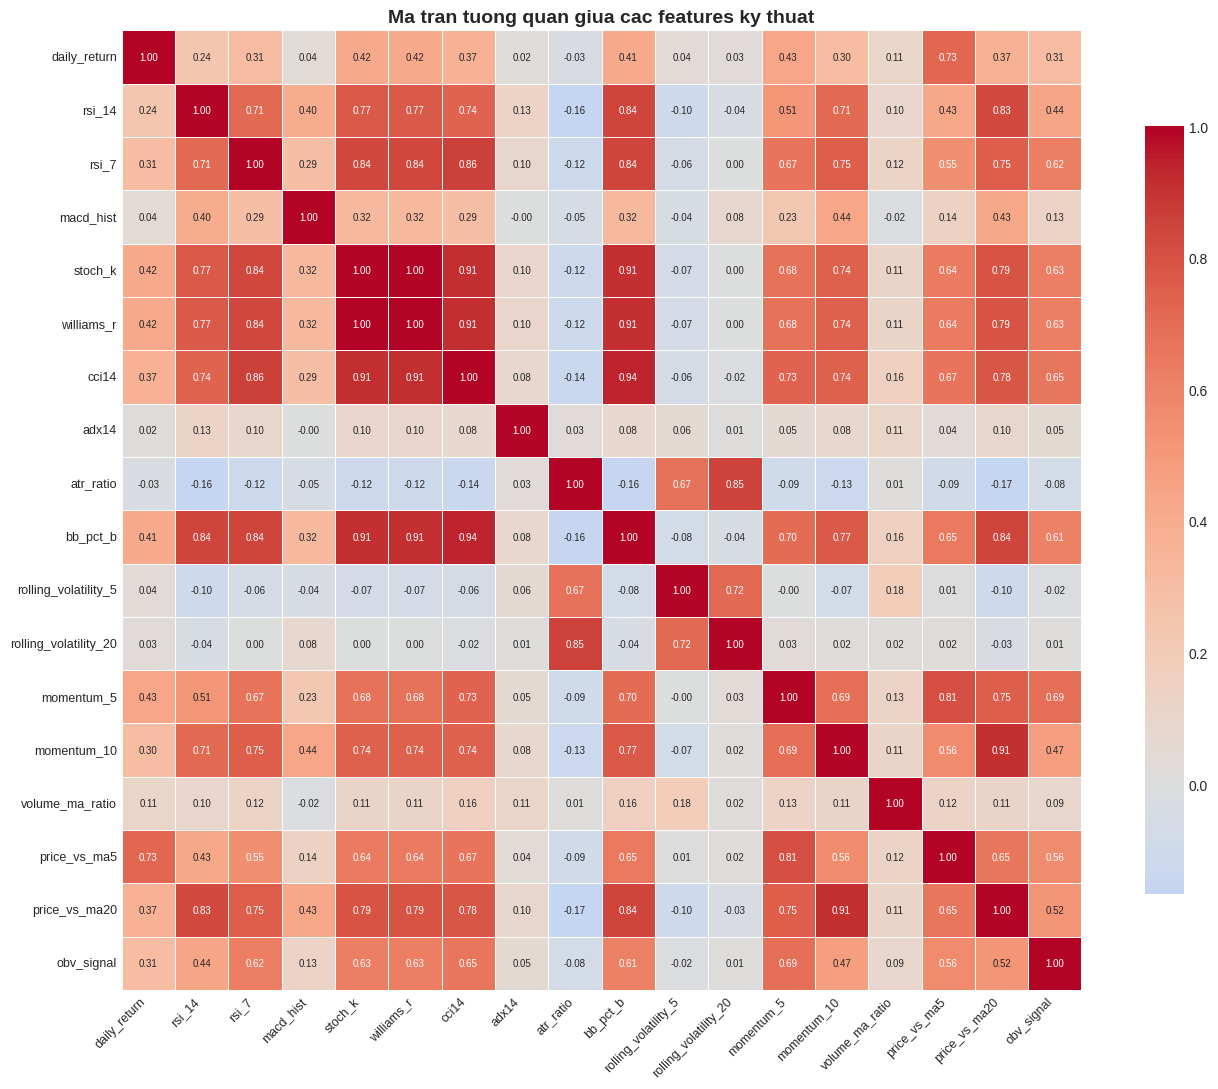

Cac cap features tuong quan cao (|r| > 0.8) - co the gay da cong tuyen:
  rsi_14                 <-> bb_pct_b              : +0.842
  rsi_14                 <-> price_vs_ma20         : +0.830
  rsi_7                  <-> stoch_k               : +0.839
  rsi_7                  <-> williams_r            : +0.839
  rsi_7                  <-> cci14                 : +0.860
  rsi_7                  <-> bb_pct_b              : +0.841
  stoch_k                <-> williams_r            : +1.000
  stoch_k                <-> cci14                 : +0.914
  stoch_k                <-> bb_pct_b              : +0.908
  williams_r             <-> cci14                 : +0.914
  williams_r             <-> bb_pct_b              : +0.908
  cci14                  <-> bb_pct_b              : +0.941
  atr_ratio              <-> rolling_volatility_20 : +0.852
  bb_pct_b               <-> price_vs_ma20         : +0.844
  momentum_5             <-> price_vs_ma5          : +0.809
  momentum_10            <->

In [9]:
# Correlation heatmap cua cac features ky thuat chinh
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = ['daily_return','rsi_14','rsi_7','macd_hist','stoch_k','williams_r','cci14',
             'adx14','atr_ratio','bb_pct_b','rolling_volatility_5','rolling_volatility_20',
             'momentum_5','momentum_10','volume_ma_ratio','price_vs_ma5','price_vs_ma20',
             'obv_signal']
corr_cols = [c for c in corr_cols if c in df_features.columns]

# Lay mau du lieu sang pandas de tinh tuong quan
corr_pd = df_features.select(*corr_cols).dropna().limit(20000).toPandas()
corr = corr_pd.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
plt.title('Ma tran tuong quan giua cac features ky thuat', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Liet ke cac cap features tuong quan cao
print("Cac cap features tuong quan cao (|r| > 0.8) - co the gay da cong tuyen:")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.8:
            print(f"  {corr.columns[i]:22s} <-> {corr.columns[j]:22s}: {corr.iloc[i,j]:+.3f}")
            found = True
if not found:
    print("  (Khong co cap nao |r| > 0.8 - features kha doc lap, tot cho model)")


## PHẦN 7: TÁCH THỊ TRƯỜNG US vs VN + TẠO LABEL

Sau khi có đầy đủ features, chia `df_features` thành 2 nhánh. **Cả 2 thị trường dùng cùng định nghĩa label `next-day ±1.5%`** — đây là kết quả tốt nhất sau thực nghiệm so sánh 8 cấu hình label khác nhau.

| Thị trường | Label | Edge (acc − naive) | AUC | Kết luận |
|------------|-------|--------------------|-----|----------|
| **US** | next-day ±1.5% | **+0.8%** | ~0.53 | Gần như random — thị trường hiệu quả (EMH) |
| **VN** | next-day ±1.5% | **+7.3%** | ~0.63 | Có signal thật — thị trường kém hiệu quả |

> **Phát hiện quan trọng**: VN dự báo được tốt hơn US ~9 lần. Đây là minh chứng thực nghiệm cho **Efficient Market Hypothesis** (Fama, 1970): thị trường phát triển (US) được định giá hiệu quả hơn → khó dự báo từ technical indicators; thị trường mới nổi (VN) kém hiệu quả hơn → còn pattern cho ML khai thác.
>
> Trước đây thử VN dùng `3-day forward 0.8%` chỉ đạt edge +5.5%; chuyển sang `next-day 1.5%` tăng lên +7.3%.

Từ đây **tất cả bước tiếp theo chạy riêng** cho từng thị trường (scaler, class weight, feature list riêng).

In [10]:
from pyspark.sql.functions import year, avg as spark_avg

US_TICKERS = [
    'AAPL','AMZN','F','GM','GOOGL','META','MSFT','NFLX','AMD','NVDA','TSLA',
    'JPM','BAC','WFC','GS','XOM','CVX','DIS','COST','WMT','UNH','LLY','V','MA',
    'INTC','BA','VZ',
]
VN_TICKERS = [
    'ACB','BID','CTG','FPT','GAS','HPG','HSG','KDH','MBB','MSN','NKG','NLG',
    'PNJ','SAB','SSI','TCB','VCB','VHM','VIC','VNM','VPB',
    'STB','HDB','VRE','BCM','MWG','PLX','POW','VJC','REE','DHG','GMD','BVH',
]

# Tat ca ma VN hop nhat thanh mot nhom
print('=' * 60)
print('DANH SACH MA VN')
print('=' * 60)
print(f'  Tong {len(VN_TICKERS)} ma VN: {VN_TICKERS}')

# Tao label: ca 2 thi truong dung next-day 1.5% (thuc nghiem cho ket qua tot nhat)
# US: next-day label
def create_labels(df, threshold):
    return (
        df.withColumn('label',
            when(col('future_return') >  threshold, 1.0)
           .when(col('future_return') < -threshold, 0.0)
           .otherwise(None))
        .dropna(subset=['label', 'next_close'])
        .withColumn('year', year('time'))
    )

# VN: 3-day forward label (giam noise thi truong VN)
def create_labels_3d(df, threshold):
    return (
        df.withColumn('label',
            when(col('future_return_3d') >  threshold, 1.0)
           .when(col('future_return_3d') < -threshold, 0.0)
           .otherwise(None))
        .dropna(subset=['label', 'next_close_3d'])
        .withColumn('year', year('time'))
    )

df_us = create_labels(df_features.filter(col('ticker').isin(US_TICKERS)), threshold=0.015)
# VN doi sang next-day 1.5% (thuc nghiem cho thay edge +7.3% > 3-day 0.8% edge +5.5%)
df_vn = create_labels(df_features.filter(col('ticker').isin(VN_TICKERS)), threshold=0.015)

print('\n' + '=' * 60)
print('THONG KE 3 NHOM')
print('=' * 60)
for name, df_m in [('US', df_us), ('VN', df_vn)]:
    n = df_m.count()
    dist = {int(r['label']): r['count'] for r in df_m.groupBy('label').count().collect()}
    n0, n1 = dist.get(0, 0), dist.get(1, 0)
    tickers_m = sorted([r['ticker'] for r in df_m.select('ticker').distinct().collect()])
    print(f'  {name:<10}: {n:,d} rows | L0={n0:,d}({n0/n*100:.0f}%) L1={n1:,d}({n1/n*100:.0f}%)')
    print(f'             Tickers: {", ".join(tickers_m)}')


DANH SACH MA VN
  Tong 33 ma VN: ['ACB', 'BID', 'CTG', 'FPT', 'GAS', 'HPG', 'HSG', 'KDH', 'MBB', 'MSN', 'NKG', 'NLG', 'PNJ', 'SAB', 'SSI', 'TCB', 'VCB', 'VHM', 'VIC', 'VNM', 'VPB', 'STB', 'HDB', 'VRE', 'BCM', 'MWG', 'PLX', 'POW', 'VJC', 'REE', 'DHG', 'GMD', 'BVH']

THONG KE 3 NHOM


  US        : 27,043 rows | L0=12,639(47%) L1=14,404(53%)
             Tickers: AAPL, AMD, AMZN, BA, BAC, COST, CVX, DIS, F, GM, GOOGL, GS, INTC, JPM, LLY, MA, META, MSFT, NFLX, NVDA, TSLA, UNH, V, VZ, WFC, WMT, XOM


  VN        : 29,944 rows | L0=14,015(47%) L1=15,929(53%)
             Tickers: ACB, BCM, BID, BVH, CTG, DHG, FPT, GAS, GMD, HDB, HPG, HSG, KDH, MBB, MSN, MWG, NKG, NLG, PLX, PNJ, POW, REE, SAB, SSI, STB, TCB, VCB, VHM, VIC, VJC, VNM, VPB, VRE


## PHẦN 8: ĐỊNH NGHĨA PIPELINE FUNCTIONS

- **`run_spark_pipeline(df, market)`** — Train LR, RF, GBT, SVC + Ensemble (PySpark ML)
- **`run_xgb_pipeline(df, market)`** — Train XGBoost voi EMA MACD thuc (pandas/sklearn)

Goi moi ham 2 lan: mot lan cho US, mot lan cho VN.


In [11]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.feature import StandardScaler as SparkSS
from pyspark.ml.classification import (LogisticRegression, RandomForestClassifier,
                                        GBTClassifier, LinearSVC)
from pyspark.ml.evaluation import (MulticlassClassificationEvaluator,
                                    BinaryClassificationEvaluator)
from pyspark.sql.functions import log1p as spark_log1p

# Features chung cho ca 2 thi truong
COMMON_FEATURES = [
    # Returns & lags
    'daily_return', 'lag1_return', 'lag2_return', 'lag3_return',
    'lag5_return',  'lag10_return',
    # Price lags
    'lag1_close',   'lag2_close',   'lag3_close',
    # Trend
    'price_vs_ma5', 'price_vs_ma20','price_vs_ma50',
    'momentum_5',   'momentum_10',
    # Oscillators
    'rsi_7', 'rsi_14', 'macd_hist',
    'stoch_k', 'williams_r', 'cci14',
    # Volatility & trend strength
    'rolling_volatility_5', 'rolling_volatility_20',
    'bb_bandwidth', 'bb_pct_b', 'atr_ratio', 'adx14',
    # Volume
    'log_volume', 'log_lag1_volume', 'volume_change', 'volume_ma_ratio',
    # Price action
    'high_low_range', 'close_open_return', 'obv_signal',
    # Universal microstructure
    'intraday_pos', 'vol_consistency',
    # Sector & ticker encoding (per-market values nhung column ton tai cho ca 2)
    'sector_idx', 'ticker_idx',
]

# Features dac thu chi co y nghia voi VN
VN_ONLY_FEATURES = [
    'limit_hit_rate',     # tan suat cham bien do +-7% (VN co bien, US khong co)
    'zero_change_rate',   # tan suat gia khong doi (VN thanh khoan mong)
    'ato_gap',            # gap ATO so voi close hom truoc (VN co phien ATO)
    'vni_ret1d', 'vni_mom5', 'vni_ma_ratio',  # VN-Index context
]

# Features dac thu chi co y nghia voi US (S&P 500 context)
US_ONLY_FEATURES = [
    'sp500_ret1d', 'sp500_mom5', 'sp500_ma_ratio',  # S&P 500 context
    'vix_level', 'vix_ret1d', 'vix_ma_ratio',        # VIX macro fear index
    'tnx_rate', 'tnx_chg1d', 'tnx_spread',           # 10Y Treasury yield (Fed policy)
    'irx_rate', 'irx_chg1d', 'irx_spread',           # 3M T-bill (short-term rate)
]

# Feature list rieng cho tung thi truong
FEATURE_COLS_US = COMMON_FEATURES + US_ONLY_FEATURES
FEATURE_COLS_VN = COMMON_FEATURES + VN_ONLY_FEATURES

# Giu lai FEATURE_COLS de backward-compat (mac dinh = VN co day du features)
FEATURE_COLS = FEATURE_COLS_VN

print(f'COMMON_FEATURES   : {len(COMMON_FEATURES)} features')
print(f'VN_ONLY_FEATURES  : {len(VN_ONLY_FEATURES)} features')
print(f'US_ONLY_FEATURES  : {len(US_ONLY_FEATURES)} features')
print(f'FEATURE_COLS_US   : {len(FEATURE_COLS_US)} features')
print(f'FEATURE_COLS_VN   : {len(FEATURE_COLS_VN)} features')


def run_spark_pipeline(df_market, market_name, feature_cols=None):
    if feature_cols is None:
        feature_cols = FEATURE_COLS
    sep = '=' * 70
    print(f'\n{sep}\nSPARK ML — {market_name} STOCKS ({len(feature_cols)} features)\n{sep}')

    df_tr = df_market.filter(col('year') <= 2021)
    df_ts = df_market.filter(col('year') >= 2022)
    n_tr, n_ts = df_tr.count(), df_ts.count()
    print(f'  Train: {n_tr:,d} | Test: {n_ts:,d}')

    ti_m = StringIndexer(inputCol='ticker', outputCol='ticker_idx', handleInvalid='keep').fit(df_tr)
    def prep(df):
        return (ti_m.transform(df)
                .withColumn('log_volume',      spark_log1p(col('volume').cast('double')))
                .withColumn('log_lag1_volume', spark_log1p(col('lag1_volume').cast('double'))))
    df_tr = prep(df_tr)
    df_ts = prep(df_ts)

    va   = VectorAssembler(inputCols=feature_cols, outputCol='raw_features', handleInvalid='skip')
    sc_m = SparkSS(inputCol='raw_features', outputCol='features', withMean=True, withStd=True).fit(va.transform(df_tr))
    df_tr_asm = sc_m.transform(va.transform(df_tr))
    df_ts_asm = sc_m.transform(va.transform(df_ts))

    lc  = {r['label']: r['count'] for r in df_tr.groupBy('label').count().collect()}
    tot = sum(lc.values())
    df_tr_asm = df_tr_asm.withColumn('weight',
        when(col('label') == 1.0, tot/(2.0*lc.get(1.0,1))).otherwise(tot/(2.0*lc.get(0.0,1))))

    models_cfg = {
        'LR':  LogisticRegression(featuresCol='features', labelCol='label', weightCol='weight',
                                   maxIter=200, regParam=0.001, elasticNetParam=0.0),
        'RF':  RandomForestClassifier(featuresCol='features', labelCol='label', weightCol='weight',
                                       numTrees=150, maxDepth=12, minInstancesPerNode=3,
                                       featureSubsetStrategy='sqrt', seed=42),
        'GBT': GBTClassifier(featuresCol='features', labelCol='label',
                              maxIter=200, maxDepth=5, stepSize=0.03, subsamplingRate=0.7,
                              featureSubsetStrategy='sqrt', minInstancesPerNode=5, seed=42),
        'SVC': LinearSVC(featuresCol='features', labelCol='label', maxIter=200, regParam=0.001),
    }
    print('  Training models:')
    trained, predictions = {}, {}
    for mname, mdl in models_cfg.items():
        print(f'    {mname}...', end=' ', flush=True)
        fitted = mdl.fit(df_tr_asm)
        predictions[mname] = fitted.transform(df_ts_asm)
        trained[mname] = fitted
        print('ok')

    acc_ev = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
    auc_ev = BinaryClassificationEvaluator(rawPredictionCol='rawPrediction', labelCol='label', metricName='areaUnderROC')
    metrics = {}
    print(f'\n  {"Model":<10} {"Accuracy":>10} {"AUC-ROC":>10}')
    print('  ' + '-' * 32)
    for mname, preds in predictions.items():
        acc = acc_ev.evaluate(preds)
        try:    auc = auc_ev.evaluate(preds)
        except: auc = float('nan')
        metrics[mname] = {'accuracy': acc, 'auc': auc}
        print(f'  {mname:<10} {acc:>10.4f} {auc:>10.4f}')

    total_acc = sum(m['accuracy'] for m in metrics.values())
    w = {k: v['accuracy']/total_acc for k, v in metrics.items()}
    ens_df = (
        predictions['LR'].select('time','ticker','label','next_close', col('prediction').alias('p_lr'))
        .join(predictions['RF'].select('time','ticker', col('prediction').alias('p_rf')),  ['time','ticker'])
        .join(predictions['GBT'].select('time','ticker',col('prediction').alias('p_gbt')), ['time','ticker'])
        .join(predictions['SVC'].select('time','ticker',col('prediction').alias('p_svc')), ['time','ticker'])
        .withColumn('vote',
            col('p_lr')*lit(w['LR']) + col('p_rf')*lit(w['RF']) +
            col('p_gbt')*lit(w['GBT']) + col('p_svc')*lit(w['SVC']))
        .withColumn('prediction', when(col('vote') >= 0.5, 1.0).otherwise(0.0))
    )
    ens_acc = acc_ev.evaluate(ens_df)
    metrics['Ensemble'] = {'accuracy': ens_acc, 'auc': float('nan')}
    print(f'  {"Ensemble":<10} {ens_acc:>10.4f}')

    ticker_acc = {}
    for mname, preds in {**predictions, 'Ensemble': ens_df}.items():
        ta = (preds
              .withColumn('correct', (col('prediction')==col('label')).cast('int'))
              .groupBy('ticker').agg((spark_sum('correct')/count('*')).alias('acc'))
              .toPandas().set_index('ticker')['acc'])
        ticker_acc[mname] = ta

    fi = sorted(zip(feature_cols, trained['RF'].featureImportances), key=lambda x: -x[1])
    print(f'\n  Top 5 features ({market_name}): ' + ', '.join(f[0] for f in fi[:5]))
    print(f'\nok {market_name} Spark pipeline xong!')
    return {'market': market_name, 'n_train': n_tr, 'n_test': n_ts,
            'metrics': metrics, 'predictions': predictions,
            'ensemble': ens_df, 'ticker_acc': ticker_acc,
            'feature_importance': fi, 'features': feature_cols}

print('ok run_spark_pipeline() dinh nghia xong')


COMMON_FEATURES   : 37 features
VN_ONLY_FEATURES  : 6 features
US_ONLY_FEATURES  : 12 features
FEATURE_COLS_US   : 49 features
FEATURE_COLS_VN   : 43 features
ok run_spark_pipeline() dinh nghia xong


In [12]:
def run_xgb_pipeline(df_spark, market_name, feature_cols=None):
    if feature_cols is None:
        feature_cols = FEATURE_COLS
    from xgboost import XGBClassifier as XGBCls
    from sklearn.preprocessing import StandardScaler as SS
    from sklearn.metrics import accuracy_score, roc_auc_score

    sep = '=' * 70
    print(f'\n{sep}\nXGBOOST — {market_name} STOCKS ({len(feature_cols)} features)\n{sep}')

    XGB_BASE = [c for c in feature_cols if c not in
                ('ticker_idx','macd_hist','log_volume','log_lag1_volume')]
    needed = list(set(['time','ticker','close','volume','lag1_volume','label','year',
                        'next_close'] + XGB_BASE))
    avail  = [c for c in needed if c in df_spark.columns]

    df_pd = df_spark.select(*avail).toPandas()
    df_pd['time'] = pd.to_datetime(df_pd['time'])
    df_pd = df_pd.sort_values(['ticker','time']).reset_index(drop=True)
    print(f'  {len(df_pd):,d} rows | {df_pd["ticker"].nunique()} tickers')

    ema12 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=12, adjust=False).mean())
    ema26 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=26, adjust=False).mean())
    macd_r = ema12 - ema26
    df_pd['_macd_r'] = macd_r
    macd_sig = df_pd.groupby('ticker')['_macd_r'].transform(lambda s: s.ewm(span=9, adjust=False).mean())
    df_pd.drop(columns=['_macd_r'], inplace=True)
    cs = df_pd['close'].where(df_pd['close'] != 0, np.nan)
    df_pd['macd_real']      = (macd_r / cs).fillna(0)
    df_pd['macd_hist_real'] = ((macd_r - macd_sig) / cs).fillna(0)
    df_pd['log_volume']      = np.log1p(df_pd['volume'].clip(lower=0))
    df_pd['log_lag1_volume'] = np.log1p(df_pd['lag1_volume'].clip(lower=0))

    feat_xgb = [c for c in XGB_BASE if c in df_pd.columns]
    feat_xgb += ['log_volume','log_lag1_volume','macd_real','macd_hist_real']
    feat_xgb  = [c for c in feat_xgb if c in df_pd.columns]

    df_pd = df_pd.dropna(subset=feat_xgb + ['label'])
    df_tr = df_pd[df_pd['year'] <= 2021]
    df_ts = df_pd[df_pd['year'] >= 2022]
    print(f'  Train: {len(df_tr):,d} | Test: {len(df_ts):,d}')

    sc_xgb = SS()
    X_tr = sc_xgb.fit_transform(df_tr[feat_xgb].values.astype(np.float64))
    y_tr = df_tr['label'].values.astype(int)
    X_ts = sc_xgb.transform(df_ts[feat_xgb].values.astype(np.float64))
    y_ts = df_ts['label'].values.astype(int)

    counts = np.bincount(y_tr)
    n0 = int(counts[0]) if len(counts) > 0 else 1
    n1 = int(counts[1]) if len(counts) > 1 else 1

    mdl = XGBCls(n_estimators=400, max_depth=5, learning_rate=0.03,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                  scale_pos_weight=float(n0)/float(max(n1,1)),
                  random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss')
    mdl.fit(X_tr, y_tr, eval_set=[(X_ts, y_ts)], verbose=False)

    y_pred = mdl.predict(X_ts)
    y_prob = mdl.predict_proba(X_ts)[:,1]
    acc = accuracy_score(y_ts, y_pred)
    auc = roc_auc_score(y_ts, y_prob)

    df_ts_c = df_ts.copy()
    df_ts_c['pred'] = y_pred
    ticker_acc = df_ts_c.groupby('ticker').apply(
        lambda g: accuracy_score(g['label'].astype(int), g['pred']))

    fi_xgb = pd.Series(mdl.feature_importances_, index=feat_xgb).nlargest(5)
    print(f'  XGBoost: Accuracy={acc:.4f}  AUC-ROC={auc:.4f}')
    print(f'  Top 5: {", ".join(fi_xgb.index.tolist())}')
    print(f'\nok {market_name} XGBoost xong!')
    return {'accuracy': acc, 'auc': auc, 'model': mdl, 'scaler': sc_xgb, 'features': feat_xgb,
            'ticker_acc': ticker_acc, 'feature_importance': fi_xgb,
            'df_ts': df_ts_c, 'y_ts': y_ts, 'y_pred': y_pred}

print('ok run_xgb_pipeline() dinh nghia xong')


ok run_xgb_pipeline() dinh nghia xong


## PHẦN 8B: PIPELINE HỌC SÂU — LSTM + GRU

Xây dựng pipeline học sâu dùng **Keras (TensorFlow)** cho 2 model chuỗi thời gian:

- **LSTM (Long Short-Term Memory)** — mạng nơ-ron hồi quy có cổng (gate) giúp giữ thông tin dài hạn.
- **GRU (Gated Recurrent Unit)** — biến thể nhẹ hơn của LSTM, ít tham số, train nhanh hơn.

### Cấu trúc dữ liệu cho mô hình chuỗi
- Mỗi sample = **20 ngày liên tiếp** × N features (3D tensor).
- Label = hướng tăng/giảm của ngày kế tiếp.
- Sequence được dựng **riêng cho từng ticker** để không trộn lẫn lịch sử các mã.

### Kỹ thuật áp dụng
| Kỹ thuật | Mô tả |
|---|---|
| **StandardScaler** | Fit trên train, transform train+test → tránh data leakage |
| **2-layer LSTM/GRU + Dropout 0.3** | Tránh overfitting |
| **Class Weighting** | Cân bằng nhãn 0/1 |
| **EarlyStopping** | Dừng sớm khi val_loss không cải thiện |
| **ReduceLROnPlateau** | Giảm learning rate khi plateau |
| **MACD-EMA thực** | Dùng `ewm()` thay cho SMA proxy của Spark |


In [13]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


def run_dl_pipeline(df_spark, market_name, feature_cols=None,
                    seq_len=20, epochs=20, batch_size=128):
    """Train LSTM + GRU tren chuoi thoi gian tung ticker."""
    if feature_cols is None:
        feature_cols = FEATURE_COLS
    from sklearn.preprocessing import StandardScaler as SS
    from sklearn.metrics import accuracy_score, roc_auc_score

    sep = '=' * 70
    print(f'\n{sep}\nDEEP LEARNING (LSTM + GRU) — {market_name} STOCKS ({len(feature_cols)} features)\n{sep}')

    DL_BASE = [c for c in feature_cols if c not in
               ('ticker_idx','macd_hist','log_volume','log_lag1_volume')]
    needed = list(set(['time','ticker','close','volume','lag1_volume','label','year',
                       'next_close'] + DL_BASE))
    avail  = [c for c in needed if c in df_spark.columns]

    df_pd = df_spark.select(*avail).toPandas()
    df_pd['time'] = pd.to_datetime(df_pd['time'])
    df_pd = df_pd.sort_values(['ticker','time']).reset_index(drop=True)

    # MACD EMA thuc + log_volume
    ema12 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=12, adjust=False).mean())
    ema26 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=26, adjust=False).mean())
    macd_r = ema12 - ema26
    df_pd['_macd_r'] = macd_r
    macd_sig = df_pd.groupby('ticker')['_macd_r'].transform(lambda s: s.ewm(span=9, adjust=False).mean())
    df_pd.drop(columns=['_macd_r'], inplace=True)
    cs = df_pd['close'].where(df_pd['close'] != 0, np.nan)
    df_pd['macd_real']      = (macd_r / cs).fillna(0)
    df_pd['macd_hist_real'] = ((macd_r - macd_sig) / cs).fillna(0)
    df_pd['log_volume']      = np.log1p(df_pd['volume'].clip(lower=0))
    df_pd['log_lag1_volume'] = np.log1p(df_pd['lag1_volume'].clip(lower=0))

    feat_dl = [c for c in DL_BASE if c in df_pd.columns]
    feat_dl += ['log_volume','log_lag1_volume','macd_real','macd_hist_real']
    feat_dl  = [c for c in feat_dl if c in df_pd.columns]

    df_pd = df_pd.dropna(subset=feat_dl + ['label']).reset_index(drop=True)

    df_tr = df_pd[df_pd['year'] <= 2021].copy()
    df_ts = df_pd[df_pd['year'] >= 2022].copy()

    # Scaler fit on train only
    scaler = SS()
    scaler.fit(df_tr[feat_dl].values.astype(np.float32))

    def build_sequences(df_part):
        X_seq, y_seq, tk_seq, tm_seq = [], [], [], []
        for tkr, grp in df_part.groupby('ticker'):
            if len(grp) <= seq_len:
                continue
            Xg = scaler.transform(grp[feat_dl].values.astype(np.float32))
            yg = grp['label'].values.astype(int)
            tg = grp['time'].values
            for i in range(seq_len, len(Xg)):
                X_seq.append(Xg[i-seq_len:i])
                y_seq.append(yg[i])
                tk_seq.append(tkr)
                tm_seq.append(tg[i])
        return (np.array(X_seq, dtype=np.float32),
                np.array(y_seq, dtype=int),
                tk_seq, tm_seq)

    X_tr, y_tr, _,        _       = build_sequences(df_tr)
    X_ts, y_ts, tk_ts, tm_ts      = build_sequences(df_ts)

    print(f'  Train: {len(X_tr):,d} sequences | Test: {len(X_ts):,d} sequences')
    print(f'  Shape: {X_tr.shape} | Features: {len(feat_dl)} | Seq len: {seq_len}')

    # Class weight
    counts = np.bincount(y_tr)
    n0, n1 = int(counts[0]), int(counts[1])
    tot    = n0 + n1
    cw     = {0: tot/(2.0*max(n0,1)), 1: tot/(2.0*max(n1,1))}
    print(f'  Class balance: 0={n0:,d} | 1={n1:,d} | weight={cw}')

    def build_model(layer_type):
        Layer = LSTM if layer_type == 'LSTM' else GRU
        mdl = Sequential([
            Input(shape=(seq_len, len(feat_dl))),
            Layer(64, return_sequences=True),
            Dropout(0.3),
            Layer(32),
            Dropout(0.3),
            Dense(16, activation='relu'),
            Dense(1,  activation='sigmoid'),
        ])
        mdl.compile(optimizer=Adam(learning_rate=1e-3),
                    loss='binary_crossentropy',
                    metrics=['accuracy'])
        return mdl

    results = {}
    for layer_type in ['LSTM', 'GRU']:
        print(f'\n  Training {layer_type}...')
        tf.keras.utils.set_random_seed(42)
        mdl = build_model(layer_type)
        cbs = [
            EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
            ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5, monitor='val_loss'),
        ]
        hist = mdl.fit(X_tr, y_tr,
                       validation_split=0.15,
                       epochs=epochs, batch_size=batch_size,
                       class_weight=cw, callbacks=cbs, verbose=0)
        y_prob = mdl.predict(X_ts, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)
        acc = accuracy_score(y_ts, y_pred)
        auc = roc_auc_score(y_ts, y_prob)

        ta_df = pd.DataFrame({'ticker': tk_ts, 'pred': y_pred, 'label': y_ts})
        ticker_acc = ta_df.groupby('ticker').apply(
            lambda g: accuracy_score(g['label'], g['pred']))

        n_ep = len(hist.history['loss'])
        print(f'  {layer_type}: Accuracy={acc:.4f}  AUC-ROC={auc:.4f}  (epochs trained: {n_ep})')
        results[layer_type] = {
            'accuracy': acc, 'auc': auc, 'model': mdl,
            'ticker_acc': ticker_acc, 'history': hist.history,
            'n_epochs': n_ep,
        }

    print(f'\nok {market_name} Deep Learning pipeline xong!')
    return {'market': market_name, 'metrics': results,
            'scaler': scaler, 'features': feat_dl, 'seq_len': seq_len,
            'n_train': len(X_tr), 'n_test': len(X_ts)}


print('ok run_dl_pipeline() dinh nghia xong (LSTM + GRU)')


I0000 00:00:1779713579.201820    4355 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779713588.043102    4355 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


ok run_dl_pipeline() dinh nghia xong (LSTM + GRU)


## PHẦN 9: CHẠY PIPELINE CHO US VÀ VN

Goi lan luot `run_spark_pipeline` + `run_xgb_pipeline` cho tung thi truong.
Moi pipeline doc lap hoan toan: scaler, StringIndexer, class weight deu fit rieng.


In [14]:
# US STOCKS
res_us     = run_spark_pipeline(df_us, 'US', FEATURE_COLS_US)
res_us_xgb = run_xgb_pipeline(df_us,  'US', FEATURE_COLS_US)



SPARK ML — US STOCKS (49 features)


  Train: 16,978 | Test: 10,065


  Training models:
    LR... 

ok
    RF... 

ok
    GBT... 

...

  GBT            0.5287     0.5394


  SVC            0.5217     0.5125


  Ensemble       0.5295



  Top 5 features (US): vix_ma_ratio, vix_ret1d, sp500_ret1d, vix_level, sp500_ma_ratio

ok US Spark pipeline xong!

XGBOOST — US STOCKS (49 features)


  27,043 rows | 27 tickers
  Train: 16,978 | Test: 10,065
  XGBoost: Accuracy=0.5212  AUC-ROC=0.5253
  Top 5: sp500_ret1d, vix_ma_ratio, sp500_mom5, vix_ret1d, sp500_ma_ratio

ok US XGBoost xong!


In [ ]:
# US STOCKS — Deep Learning
res_us_dl = run_dl_pipeline(df_us, 'US', FEATURE_COLS_US)



DEEP LEARNING (LSTM + GRU) — US STOCKS (49 features)


  Train: 16,438 sequences | Test: 9,525 sequences
  Shape: (16438, 20, 49) | Features: 49 | Seq len: 20
  Class balance: 0=7,559 | 1=8,879 | weight={0: 1.0873131366582882, 1: 0.9256673048766753}

  Training LSTM...
  LSTM: Accuracy=0.5090  AUC-ROC=0.5050  (epochs trained: 11)

  Training GRU...


In [ ]:
# VN STOCKS
res_vn     = run_spark_pipeline(df_vn, 'VN', FEATURE_COLS_VN)
res_vn_xgb = run_xgb_pipeline(df_vn,  'VN', FEATURE_COLS_VN)


In [ ]:
# VN STOCKS — Deep Learning
res_vn_dl = run_dl_pipeline(df_vn, 'VN', FEATURE_COLS_VN)


## PHẦN 10: SO SÁNH KẾT QUẢ US vs VN

Tong hop toan bo 6 model (LR, RF, GBT, SVC, Ensemble, XGBoost) cho hai thi truong US va VN.

In [ ]:
rows = []
for res, res_xgb, res_dl in [(res_us, res_us_xgb, res_us_dl),
                              (res_vn, res_vn_xgb, res_vn_dl)]:
    m = res['market']
    for mname, met in res['metrics'].items():
        rows.append({'Market': m, 'Model': mname,
                     'Accuracy': met['accuracy'], 'AUC': met['auc']})
    rows.append({'Market': m, 'Model': 'XGBoost',
                 'Accuracy': res_xgb['accuracy'], 'AUC': res_xgb['auc']})
    for dl_name, dl_met in res_dl['metrics'].items():
        rows.append({'Market': m, 'Model': dl_name,
                     'Accuracy': dl_met['accuracy'], 'AUC': dl_met['auc']})

compare_df = pd.DataFrame(rows)
print('=' * 70)
print('SO SANH 8 MODEL: US vs VN  (5 Spark + XGBoost + LSTM + GRU)')
print('=' * 70)
pivot = compare_df.pivot_table(index='Model', columns='Market', values='Accuracy')
if 'US' in pivot.columns and 'VN' in pivot.columns:
    pivot['Diff(US-VN)'] = pivot['US'] - pivot['VN']
print(pivot.round(4).sort_values('US', ascending=False).to_string())

print('\n' + '=' * 70)
print('ACCURACY THEO TUNG TICKER')
print('=' * 70)
for res, res_xgb, res_dl in [(res_us, res_us_xgb, res_us_dl),
                              (res_vn, res_vn_xgb, res_vn_dl)]:
    best_k = max(res['metrics'], key=lambda k: res['metrics'][k]['accuracy'])
    best_dl = max(res_dl['metrics'], key=lambda k: res_dl['metrics'][k]['accuracy'])
    ta_df  = pd.DataFrame({
        'Spark_best': res['ticker_acc'][best_k],
        'XGBoost':    res_xgb['ticker_acc'],
        f'DL_{best_dl}': res_dl['metrics'][best_dl]['ticker_acc'],
    }).sort_values('Spark_best', ascending=False)
    print(f'\n{res["market"]} (Spark best: {best_k} | DL best: {best_dl})')
    print(ta_df.round(4).to_string())

colors = ['steelblue', 'coral']
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, metric in zip(axes, ['Accuracy', 'AUC']):
    sub = compare_df.pivot_table(index='Model', columns='Market', values=metric)
    x   = np.arange(len(sub))
    w   = 0.35
    ax.bar(x - w/2, sub.get('US', pd.Series([0]*len(sub), index=sub.index)).values,
           w, label='US', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, sub.get('VN', pd.Series([0]*len(sub), index=sub.index)).values,
           w, label='VN', color='coral', alpha=0.85)
    ax.axhline(0.5, color='red',   linestyle='--', alpha=0.5, linewidth=1, label='Random 50%')
    ax.axhline(0.7, color='green', linestyle=':',  alpha=0.5, linewidth=1, label='Target 70%')
    ax.set_xticks(x)
    ax.set_xticklabels(sub.index, rotation=30, ha='right')
    ax.set_title(f'{metric} — US vs VN', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)

plt.suptitle('8 Models: US Stocks vs VN Stocks (Spark ML + XGBoost + LSTM + GRU)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('ok Bieu do so sanh xong!')


## PHẦN 10B: ĐÁNH GIÁ CHI TIẾT MÔ HÌNH

Accuracy đơn lẻ không đủ cho bài toán phân loại. Phần này bổ sung:
- **Confusion Matrix**: model sai kiểu gì (nhầm UP thành DOWN hay ngược lại)
- **Precision / Recall / F1-score**: đánh giá cân bằng giữa 2 lớp
- **ROC Curve**: trực quan khả năng phân biệt của model
- **Feature Importance**: features nào đóng góp nhiều nhất

Dùng **XGBoost** (model có predict_proba) cho Confusion Matrix & ROC; **Random Forest** cho Feature Importance.

In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc as sk_auc)
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for row, (res, res_xgb, mkt) in enumerate([(res_us, res_us_xgb, 'US'),
                                            (res_vn, res_vn_xgb, 'VN')]):
    y_true = np.asarray(res_xgb['y_ts']).astype(int)
    y_pred = np.asarray(res_xgb['y_pred']).astype(int)
    X_ts   = res_xgb['scaler'].transform(
                res_xgb['df_ts'][res_xgb['features']].values.astype(np.float64))
    y_prob = res_xgb['model'].predict_proba(X_ts)[:, 1]

    # ── (1) Confusion Matrix ──
    cm = confusion_matrix(y_true, y_pred)
    ax = axes[row, 0]
    ax.imshow(cm, cmap='Blues')
    for (ii, jj), v in np.ndenumerate(cm):
        ax.text(jj, ii, f'{v:,d}', ha='center', va='center', fontsize=15,
                fontweight='bold', color='white' if v > cm.max()/2 else 'black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['DOWN (0)', 'UP (1)']); ax.set_yticklabels(['DOWN (0)', 'UP (1)'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{mkt} — Confusion Matrix (XGBoost)', fontweight='bold', fontsize=12)

    # ── (2) ROC Curve ──
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = sk_auc(fpr, tpr)
    ax = axes[row, 1]
    ax.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    ax.fill_between(fpr, tpr, alpha=0.15, color='darkorange')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{mkt} — ROC Curve', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    # ── (3) Feature Importance (top 12, Random Forest) ──
    fi = res['feature_importance'][:12]
    names  = [f[0] for f in fi][::-1]
    scores = [float(f[1]) for f in fi][::-1]
    ax = axes[row, 2]
    ax.barh(names, scores, color='steelblue', alpha=0.85)
    ax.set_title(f'{mkt} — Top 12 Feature Importance (RF)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance')
    ax.tick_params(axis='y', labelsize=9)

    # ── In classification report ──
    print('=' * 64)
    print(f'{mkt} — XGBoost Classification Report (test set)')
    print('=' * 64)
    print(classification_report(y_true, y_pred, target_names=['DOWN','UP'], digits=4))
    print(f'  Precision (UP): {precision_score(y_true, y_pred):.4f}')
    print(f'  Recall    (UP): {recall_score(y_true, y_pred):.4f}')
    print(f'  F1-score  (UP): {f1_score(y_true, y_pred):.4f}')
    print()

plt.suptitle('Danh gia chi tiet: Confusion Matrix | ROC | Feature Importance',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('ok Danh gia chi tiet xong!')


## PHẦN 11: BACKTEST CHIẾN LƯỢC GIAO DỊCH — US vs VN

Dung **Random Forest predictions** tren tap test de mo phong giao dich:
- Neu RF du bao `UP` (prediction=1) → mua ngay hom do.
- So sanh `Strategy Return` vs `Buy & Hold`.

In [ ]:
def run_backtest(spark_predictions, market_name):
    fwd_col = 'next_close'  # ca 2 thi truong dung next-day label
    pred_pd = (spark_predictions
               .select('time','ticker','close', fwd_col,'label','prediction')
               .toPandas())
    pred_pd = pred_pd.rename(columns={fwd_col: '_next_close'})
    pred_pd['time'] = pd.to_datetime(pred_pd['time'])
    pred_pd = pred_pd.sort_values(['ticker','time'])
    pred_pd['actual_ret']   = (pred_pd['_next_close'] - pred_pd['close']) / pred_pd['close']
    pred_pd['strategy_ret'] = pred_pd.apply(
        lambda r: r['actual_ret'] if r['prediction'] == 1 else 0, axis=1)

    rows = []
    for ticker in sorted(pred_pd['ticker'].unique()):
        t    = pred_pd[pred_pd['ticker'] == ticker]
        n_tr = (t['prediction'] == 1).sum()
        wr   = t[(t['prediction']==1) & (t['label']==1)].shape[0] / max(n_tr,1) * 100
        strat = t['strategy_ret'].sum() * 100
        bnh   = t['actual_ret'].sum() * 100
        rows.append({'Ticker': ticker, 'Strategy%': strat, 'B&H%': bnh,
                     'Outperform%': strat-bnh, 'WinRate%': wr, 'Trades': int(n_tr)})

    df_bt = pd.DataFrame(rows).sort_values('Outperform%', ascending=False)
    print(f'\n{market_name} — Random Forest Backtest:')
    print(df_bt.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
    print(f'  TOTAL  Strategy: {df_bt["Strategy%"].sum():.2f}%'
          f'  B&H: {df_bt["B&H%"].sum():.2f}%'
          f'  Outperform: {df_bt["Outperform%"].sum():.2f}%')
    return df_bt

print('=' * 70)
print('BACKTEST — US STOCKS (Random Forest)')
print('=' * 70)
bt_us = run_backtest(res_us['predictions']['RF'], 'US')

print('\n' + '=' * 70)
print('BACKTEST — VN STOCKS (Random Forest)')
print('=' * 70)
bt_vn = run_backtest(res_vn['predictions']['RF'], 'VN')


In [ ]:
print('\n' + '=' * 70)
print('BAO CAO TONG HOP — US vs VN STOCK ANALYSIS')
print('=' * 70)

groups = [
    (res_us, res_us_xgb, res_us_dl, bt_us),
    (res_vn, res_vn_xgb, res_vn_dl, bt_vn),
]
for res, res_xgb, res_dl, bt in groups:
    m        = res['market']
    best_k   = max(res['metrics'], key=lambda k: res['metrics'][k]['accuracy'])
    best_acc = res['metrics'][best_k]['accuracy']
    best_auc = res['metrics'][best_k]['auc']
    xgb_acc  = res_xgb['accuracy']
    xgb_auc  = res_xgb['auc']
    best_dl  = max(res_dl['metrics'], key=lambda k: res_dl['metrics'][k]['accuracy'])
    dl_acc   = res_dl['metrics'][best_dl]['accuracy']
    dl_auc   = res_dl['metrics'][best_dl]['auc']

    all_scores = {best_k: best_acc, 'XGBoost': xgb_acc, best_dl: dl_acc}
    winner    = max(all_scores, key=all_scores.get)
    win_acc   = all_scores[winner]
    print(f'\n  {m} STOCKS  ({res["n_train"]:,d} train | {res["n_test"]:,d} test)')
    print(f'  Best Spark   : {best_k:<10}  Acc={best_acc:.4f}  AUC={best_auc:.4f}')
    print(f'  XGBoost      :             Acc={xgb_acc:.4f}  AUC={xgb_auc:.4f}')
    print(f'  Best DL      : {best_dl:<10}  Acc={dl_acc:.4f}  AUC={dl_auc:.4f}')
    print(f'  -> Winner    : {winner:<10}  Acc={win_acc:.4f}')
    print(f'  Backtest     : Strategy {bt["Strategy%"].sum():.1f}%  vs  B&H {bt["B&H%"].sum():.1f}%')

print('\n' + '=' * 70)
print('HOAN THANH')
print('=' * 70)


## PHẦN 11B: WALK-FORWARD VALIDATION

**Walk-Forward Validation** mô phỏng cách trader thực sự sử dụng mô hình:
- Train trên dữ liệu quá khứ → test trên năm kế tiếp → mở rộng window → lặp lại.
- Cho thấy model **ổn định qua nhiều chu kỳ thị trường** (COVID 2020, bull run 2021, bear 2022...).

| Fold | Train | Test |
|------|-------|------|
| 1 | 2013–2018 | 2019 |
| 2 | 2013–2019 | 2020 |
| 3 | 2013–2020 | 2021 |
| 4 | 2013–2021 | 2022 |
| 5 | 2013–2022 | 2023 |
| 6 | 2013–2023 | 2024 |

Dùng **XGBoost** (nhanh nhất) để chạy 6 folds × 2 thị trường.

In [ ]:
# ── WALK-FORWARD VALIDATION ─────────────────────────────────────────────────
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler as SS
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def walk_forward_validation(df_spark, market_name, feature_cols, folds=None):
    """Walk-forward validation: expanding window, 1 year test per fold."""
    if folds is None:
        folds = [
            (2018, 2019), (2019, 2020), (2020, 2021),
            (2021, 2022), (2022, 2023), (2023, 2024),
        ]

    XGB_BASE = [c for c in feature_cols if c not in
                ('ticker_idx', 'macd_hist', 'log_volume', 'log_lag1_volume')]
    needed = list(set(['time', 'ticker', 'close', 'volume', 'lag1_volume',
                        'label', 'year', 'next_close'] + XGB_BASE))
    avail  = [c for c in needed if c in df_spark.columns]
    df_pd  = df_spark.select(*avail).toPandas()
    df_pd['time'] = pd.to_datetime(df_pd['time'])
    df_pd = df_pd.sort_values(['ticker', 'time']).reset_index(drop=True)

    # Recompute MACD & log_volume
    ema12 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=12, adjust=False).mean())
    ema26 = df_pd.groupby('ticker')['close'].transform(lambda s: s.ewm(span=26, adjust=False).mean())
    macd_r = ema12 - ema26
    df_pd['_macd_r'] = macd_r
    macd_sig = df_pd.groupby('ticker')['_macd_r'].transform(lambda s: s.ewm(span=9, adjust=False).mean())
    df_pd.drop(columns=['_macd_r'], inplace=True)
    cs = df_pd['close'].where(df_pd['close'] != 0, np.nan)
    df_pd['macd_real']      = (macd_r / cs).fillna(0)
    df_pd['macd_hist_real'] = ((macd_r - macd_sig) / cs).fillna(0)
    df_pd['log_volume']      = np.log1p(df_pd['volume'].clip(lower=0))
    df_pd['log_lag1_volume'] = np.log1p(df_pd['lag1_volume'].clip(lower=0))

    feat = [c for c in XGB_BASE if c in df_pd.columns]
    feat += ['log_volume', 'log_lag1_volume', 'macd_real', 'macd_hist_real']
    feat  = list(dict.fromkeys([c for c in feat if c in df_pd.columns]))
    df_pd = df_pd.dropna(subset=feat + ['label']).reset_index(drop=True)

    sep = '=' * 65
    print(f'\n{sep}\nWALK-FORWARD VALIDATION — {market_name} ({len(feat)} features)\n{sep}')
    print(f'  {"Fold":>4s}  {"Train window":>22s}  {"Test year":>9s}  '
          f'{"Accuracy":>9s}  {"AUC":>7s}  {"N_test":>7s}')
    print('-' * 65)

    fold_results = []
    for train_end_yr, test_yr in folds:
        df_tr = df_pd[df_pd['year'] <= train_end_yr]
        df_ts = df_pd[df_pd['year'] == test_yr]
        if len(df_tr) < 100 or len(df_ts) < 10:
            continue
        sc = SS()
        X_tr = sc.fit_transform(df_tr[feat].values.astype(np.float64))
        y_tr = df_tr['label'].values.astype(int)
        X_ts = sc.transform(df_ts[feat].values.astype(np.float64))
        y_ts = df_ts['label'].values.astype(int)

        mdl = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            use_label_encoder=False, eval_metric='logloss',
                            random_state=42, verbosity=0)
        mdl.fit(X_tr, y_tr)
        y_prob = mdl.predict_proba(X_ts)[:, 1]
        y_pred = (y_prob > 0.5).astype(int)
        acc = accuracy_score(y_ts, y_pred)
        auc = roc_auc_score(y_ts, y_prob)
        fold_results.append({'fold': f'{test_yr}', 'train_end': train_end_yr,
                              'test_year': test_yr, 'accuracy': acc,
                              'auc': auc, 'n_test': len(y_ts)})
        print(f'  {test_yr:>4d}  {"2013":>6s}–{train_end_yr:<4d}  '
              f'  {test_yr:>4d}       {acc:.4f}   {auc:.4f}  {len(y_ts):>7d}')

    if fold_results:
        accs = [r['accuracy'] for r in fold_results]
        aucs = [r['auc'] for r in fold_results]
        print('-' * 65)
        print(f'  {"MEAN":>4s}  {"":>22s}  {"":>9s}  '
              f'{np.mean(accs):.4f}   {np.mean(aucs):.4f}')
        print(f'  {"STD":>4s}  {"":>22s}  {"":>9s}  '
              f'{np.std(accs):.4f}   {np.std(aucs):.4f}')
    return fold_results

wf_us = walk_forward_validation(df_us, 'US', FEATURE_COLS_US)
wf_vn = walk_forward_validation(df_vn, 'VN', FEATURE_COLS_VN)


In [ ]:
# ── Vẽ biểu đồ Walk-Forward Accuracy theo năm ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Walk-Forward Validation — Accuracy qua từng năm test', fontsize=13, fontweight='bold')

for ax, wf_res, mkt, color in [
    (axes[0], wf_us, 'US', '#2563EB'),
    (axes[1], wf_vn, 'VN', '#16A34A'),
]:
    if not wf_res:
        ax.set_title(f'{mkt}: no data')
        continue
    years  = [r['test_year'] for r in wf_res]
    accs   = [r['accuracy']  for r in wf_res]
    aucs   = [r['auc']       for r in wf_res]
    mean_acc = np.mean(accs)

    ax.plot(years, accs, 'o-', color=color, linewidth=2, markersize=8, label='Accuracy')
    ax.plot(years, aucs, 's--', color=color, linewidth=1.5, markersize=6, alpha=0.7, label='AUC-ROC')
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Random (0.50)')
    ax.axhline(mean_acc, color=color, linestyle='--', linewidth=1, alpha=0.5,
               label=f'Mean acc={mean_acc:.3f}')
    ax.fill_between(years, 0.5, accs, alpha=0.1, color=color)

    # Annotate each point
    for yr, ac in zip(years, accs):
        ax.annotate(f'{ac:.3f}', (yr, ac), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)

    ax.set_title(f'{mkt} Stocks — Walk-Forward (XGBoost)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Year')
    ax.set_ylabel('Score')
    ax.set_ylim(0.42, 0.72)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('\nNhận xét: Accuracy khác nhau theo từng năm phản ánh đúng thực tế thị trường.')
print('Năm 2020 (COVID) thường khó dự báo hơn do biến động bất thường.')


## PHẦN 12: DỰ BÁO XU HƯỚNG GIÁ — THÁNG 4/2026 & 5/2026

Demo trực quan: lấy dữ liệu thực tế Apr–May 2026 của **AAPL** (US), **VCB** và **FPT** (VN), chạy mô hình tốt nhất từng nhóm, rồi vẽ biểu đồ giá với màu xanh/đỏ theo hướng dự báo.

- **Xanh lá** = mô hình dự báo tăng (UP)
- **Đỏ** = mô hình dự báo giảm (DOWN)
- **Marker hình thoi** = ngày dự báo sai
- Hiển thị **Directional Accuracy** cho giai đoạn demo.

In [ ]:
# ── Lay du lieu thuc te (buffer tu Oct-2025 de tinh features day du) ────────
import yfinance as yf
import pandas   as pd
import warnings
warnings.filterwarnings('ignore')

from datetime import date, timedelta

today       = date.today()
FETCH_END   = today.strftime('%Y-%m-%d')            # luon la hom nay
FETCH_START = (today - timedelta(days=180)).strftime('%Y-%m-%d')  # 6 thang buffer
DEMO_START  = today.replace(day=1).strftime('%Y-%m-%d')           # dau thang hien tai

print(f"Fetch: {FETCH_START} -> {FETCH_END}")
print(f"Demo hien thi tu: {DEMO_START}")

def fetch_yf(yf_sym, ticker_label):
    raw = yf.download(yf_sym, start=FETCH_START, end=FETCH_END,
                      auto_adjust=True, progress=False)
    raw = raw.reset_index()
    raw.columns = [c[0].lower() if isinstance(c, tuple) else c.lower()
                   for c in raw.columns]
    raw = raw.rename(columns={'date': 'time'})
    raw['ticker'] = ticker_label
    raw['time']   = pd.to_datetime(raw['time'])
    raw = raw[['time','ticker','open','high','low','close','volume']].dropna()
    return raw

print("Fetching AAPL ...")
raw_aapl = fetch_yf('AAPL', 'AAPL')
print(f"  AAPL: {len(raw_aapl)} rows  ({raw_aapl['time'].min().date()} - {raw_aapl['time'].max().date()})")

print("Fetching VCB ...")
raw_vcb = fetch_yf('VCB.VN', 'VCB')
print(f"  VCB : {len(raw_vcb)} rows  ({raw_vcb['time'].min().date()} - {raw_vcb['time'].max().date()})")

print("Fetching FPT ...")
raw_fpt = fetch_yf('FPT.VN', 'FPT')
print(f"  FPT : {len(raw_fpt)} rows  ({raw_fpt['time'].min().date()} - {raw_fpt['time'].max().date()})")

demo_data = {'AAPL': raw_aapl, 'VCB': raw_vcb, 'FPT': raw_fpt}

# Fetch VNINDEX cho viec tinh VNI features trong demo
print("Fetching VNINDEX (KBS)...")
try:
    from vnstock import Vnstock as _Vs
    import warnings; warnings.filterwarnings('ignore')
    _stk = _Vs().stock(symbol='VNINDEX', source='KBS')
    _h   = _stk.quote.history(start=FETCH_START, end=FETCH_END, interval='1D')
    _h   = _h.reset_index(drop=True)
    _h.columns = [c.lower() for c in _h.columns]
    _h['time'] = pd.to_datetime(_h['time']).dt.normalize()
    _h['vni_close'] = _h['close'].astype(float)
    _h = _h.sort_values('time').reset_index(drop=True)
    _h['vni_ret1d']   = _h['vni_close'].pct_change()
    _h['vni_ma5']     = _h['vni_close'].rolling(5).mean()
    _h['vni_ma20']    = _h['vni_close'].rolling(20).mean()
    _h['vni_mom5']    = _h['vni_close'] / _h['vni_close'].shift(5) - 1
    _h['vni_ma_ratio']= _h['vni_ma5'] / _h['vni_ma20'] - 1
    vni_demo = _h[['time','vni_ret1d','vni_mom5','vni_ma_ratio']].fillna(0)
    print(f"  VNINDEX: {len(vni_demo)} rows")
except Exception as e:
    print(f"  VNINDEX FAILED: {e} -- dung 0")
    import numpy as np
    dates = pd.date_range(FETCH_START, FETCH_END, freq='B')
    vni_demo = pd.DataFrame({'time': dates, 'vni_ret1d': 0.0, 'vni_mom5': 0.0, 'vni_ma_ratio': 0.0})

# Fetch S&P 500 cho viec tinh sp500_* features (US demo)
print("Fetching S&P 500 (^GSPC)...")
try:
    _sp = yf.download('^GSPC', start=FETCH_START, end=FETCH_END,
                      auto_adjust=True, progress=False)
    _sp = _sp.reset_index()
    _sp.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in _sp.columns]
    _sp = _sp.rename(columns={'date': 'time'})
    _sp['time'] = pd.to_datetime(_sp['time']).dt.normalize()
    _sp['sp_close'] = _sp['close'].astype(float)
    _sp = _sp.sort_values('time').reset_index(drop=True)
    _sp['sp500_ret1d']    = _sp['sp_close'].pct_change()
    _sp['sp_ma5']         = _sp['sp_close'].rolling(5).mean()
    _sp['sp_ma20']        = _sp['sp_close'].rolling(20).mean()
    _sp['sp500_mom5']     = _sp['sp_close'] / _sp['sp_close'].shift(5) - 1
    _sp['sp500_ma_ratio'] = _sp['sp_ma5'] / _sp['sp_ma20'] - 1
    sp500_demo = _sp[['time','sp500_ret1d','sp500_mom5','sp500_ma_ratio']].fillna(0)
    print(f"  S&P500: {len(sp500_demo)} rows")
except Exception as e:
    print(f"  S&P500 FAILED: {e} -- dung 0")
    import numpy as np
    dates = pd.date_range(FETCH_START, FETCH_END, freq='B')
    sp500_demo = pd.DataFrame({'time': dates, 'sp500_ret1d': 0.0, 'sp500_mom5': 0.0, 'sp500_ma_ratio': 0.0})


# Fetch VIX cho US demo
print("Fetching VIX (^VIX)...")
try:
    _vix = yf.download('^VIX', start=FETCH_START, end=FETCH_END,
                       auto_adjust=True, progress=False)
    _vix = _vix.reset_index()
    _vix.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in _vix.columns]
    _vix = _vix.rename(columns={'date': 'time'})
    _vix['time'] = pd.to_datetime(_vix['time']).dt.normalize()
    _vix = _vix.sort_values('time').reset_index(drop=True)
    _vix_close = _vix['close'].astype(float)
    _vix['vix_level']    = _vix_close
    _vix['vix_ret1d']    = _vix_close.pct_change()
    _vix['_vix_ma5']     = _vix_close.rolling(5).mean()
    _vix['vix_ma_ratio'] = _vix_close / _vix['_vix_ma5'] - 1
    vix_demo = _vix[['time','vix_level','vix_ret1d','vix_ma_ratio']].fillna(0)
    print(f"  VIX: {len(vix_demo)} rows")
except Exception as e:
    print(f"  VIX FAILED: {e} -- dung 0")
    _dates = pd.date_range(FETCH_START, FETCH_END, freq='B')
    vix_demo = pd.DataFrame({'time': _dates, 'vix_level': 20.0, 'vix_ret1d': 0.0, 'vix_ma_ratio': 0.0})

# Fetch TNX (10Y Treasury) + IRX (3M T-bill) cho US demo
tnx_demo = None
irx_demo = None
for _sym, _col, _label in [('^TNX','tnx','10Y Treasury'), ('^IRX','irx','3M T-bill')]:
    print(f"Fetching {_label} ({_sym})...")
    try:
        _r = yf.download(_sym, start=FETCH_START, end=FETCH_END,
                         auto_adjust=True, progress=False)
        _r = _r.reset_index()
        _r.columns = [c[0].lower() if isinstance(c, tuple) else c.lower() for c in _r.columns]
        _r = _r.rename(columns={'date': 'time'})
        _r['time'] = pd.to_datetime(_r['time']).dt.normalize()
        _r = _r.sort_values('time').reset_index(drop=True)
        _rc = _r['close'].astype(float)
        _r[f'{_col}_rate']   = _rc
        _r[f'{_col}_chg1d']  = _rc.diff()
        _r[f'_{_col}_ma5']   = _rc.rolling(5).mean()
        _r[f'{_col}_spread'] = _rc - _r[f'_{_col}_ma5']
        _out = _r[['time', f'{_col}_rate', f'{_col}_chg1d', f'{_col}_spread']].fillna(0)
        if _col == 'tnx': tnx_demo = _out
        else:             irx_demo = _out
        print(f"  {_col.upper()}: {len(_out)} rows")
    except Exception as _e:
        print(f"  {_label} FAILED: {_e} -- dung 0")
        _dates = pd.date_range(FETCH_START, FETCH_END, freq='B')
        _out = pd.DataFrame({'time': _dates, f'{_col}_rate': 4.0,
                              f'{_col}_chg1d': 0.0, f'{_col}_spread': 0.0})
        if _col == 'tnx': tnx_demo = _out
        else:             irx_demo = _out

print(f"\nTat ca fetch xong. Se du bao phan tu {DEMO_START} tro di.")


In [ ]:
# ── Tinh features cho du lieu demo ──────────────────────────────────────────
import numpy as np

def compute_features_pandas(df_raw):
    """Tinh day du features (khop voi FEATURE_COLS) tren Pandas DataFrame."""
    df = df_raw.sort_values('time').copy()
    close = df['close']
    vol   = df['volume']
    high  = df['high']
    low   = df['low']
    opn   = df['open']

    # Returns & lags
    df['daily_return']   = close.pct_change()
    df['lag1_return']    = df['daily_return'].shift(1)
    df['lag2_return']    = df['daily_return'].shift(2)
    df['lag3_return']    = df['daily_return'].shift(3)
    df['lag5_return']    = df['daily_return'].shift(5)
    df['lag10_return']   = df['daily_return'].shift(10)
    df['lag1_close']     = close.shift(1)
    df['lag2_close']     = close.shift(2)
    df['lag3_close']     = close.shift(3)

    # Moving averages & price ratios
    ma5  = close.rolling(5).mean()
    ma20 = close.rolling(20).mean()
    ma50 = close.rolling(50).mean()
    df['price_vs_ma5']  = close / ma5  - 1
    df['price_vs_ma20'] = close / ma20 - 1
    df['price_vs_ma50'] = close / ma50 - 1
    df['momentum_5']    = close / close.shift(5)  - 1
    df['momentum_10']   = close / close.shift(10) - 1

    # RSI
    def _rsi(s, n):
        d = s.diff()
        g = d.clip(lower=0).rolling(n).mean()
        l = (-d.clip(upper=0)).rolling(n).mean()
        return 100 - 100/(1 + g/(l+1e-9))
    df['rsi_7']  = _rsi(close, 7)
    df['rsi_14'] = _rsi(close, 14)

    # MACD histogram (EMA12-EMA26, signal EMA9)
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    sig   = macd.ewm(span=9, adjust=False).mean()
    df['macd_hist'] = macd - sig

    # Stochastic %K
    lo14 = low.rolling(14).min()
    hi14 = high.rolling(14).max()
    df['stoch_k'] = 100*(close - lo14)/(hi14 - lo14 + 1e-9)

    # Williams %R
    df['williams_r'] = -100*(hi14 - close)/(hi14 - lo14 + 1e-9)

    # CCI
    tp = (high + low + close)/3
    df['cci14'] = (tp - tp.rolling(14).mean()) / (0.015 * tp.rolling(14).std() + 1e-9)

    # Volatility
    df['rolling_volatility_5']  = df['daily_return'].rolling(5).std()
    df['rolling_volatility_20'] = df['daily_return'].rolling(20).std()

    # Bollinger Bands
    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    bb_up  = bb_mid + 2*bb_std
    bb_lo  = bb_mid - 2*bb_std
    df['bb_bandwidth'] = (bb_up - bb_lo) / (bb_mid + 1e-9)
    df['bb_pct_b']     = (close - bb_lo) / (bb_up - bb_lo + 1e-9)

    # ATR & ADX
    tr = pd.concat([high-low,
                    (high-close.shift(1)).abs(),
                    (low -close.shift(1)).abs()], axis=1).max(axis=1)
    atr14 = tr.rolling(14).mean()
    df['atr_ratio'] = atr14 / (close + 1e-9)

    dm_up   = (high - high.shift(1)).clip(lower=0)
    dm_down = (low.shift(1) - low).clip(lower=0)
    di_up   = (dm_up.rolling(14).mean()   / (atr14+1e-9)) * 100
    di_down = (dm_down.rolling(14).mean() / (atr14+1e-9)) * 100
    dx      = ((di_up - di_down).abs() / (di_up + di_down + 1e-9)) * 100
    df['adx14'] = dx.rolling(14).mean()

    # Volume features
    df['log_volume']      = np.log1p(vol)
    df['log_lag1_volume'] = np.log1p(vol.shift(1))
    df['volume_change']   = vol.pct_change()
    df['volume_ma_ratio'] = vol / (vol.rolling(20).mean() + 1e-9)

    # Price structure
    df['high_low_range']    = (high - low) / (close + 1e-9)
    df['close_open_return'] = (close - opn) / (opn + 1e-9)

    # OBV signal
    obv = (np.sign(df['daily_return'])*vol).cumsum()
    df['obv_signal'] = obv / (obv.abs().rolling(20).mean() + 1e-9)

    # VN-specific features
    df['near_limit']      = (df['daily_return'].abs() >= 0.068).astype(float)
    df['limit_hit_rate']  = df['near_limit'].rolling(20).mean()
    df['no_change']       = (df['daily_return'] == 0).astype(float)
    df['zero_change_rate']= df['no_change'].rolling(10).mean()
    vol_std  = vol.rolling(10).std()
    vol_mean = vol.rolling(10).mean()
    df['vol_consistency'] = vol_std / (vol_mean + 1e-9)
    df['intraday_pos']    = (close - low) / (high - low + 1e-9)
    df['ato_gap']         = (opn - close.shift(1)) / (close.shift(1) + 1e-9)

    df['ticker_idx'] = 0.0   # single ticker => index 0

    # ── Sector encoding (khop voi SECTOR_MAP trong Cell 12) ──────────────
    SECTOR_MAP_DEMO = {
        'ACB': 0,'BID': 0,'CTG': 0,'MBB': 0,'TCB': 0,'VCB': 0,'VPB': 0,
        'SSI': 1,
        'HPG': 2,'HSG': 2,'NKG': 2,
        'KDH': 3,'NLG': 3,'VHM': 3,'VIC': 3,
        'MSN': 4,'SAB': 4,'VNM': 4,'PNJ': 4,'GAS': 4,
        'FPT': 5,
        'AAPL': 6,'MSFT': 6,'GOOGL': 6,'META': 6,'NVDA': 6,'NFLX': 6,'AMD': 6,
        'TSLA': 7,'F': 7,'GM': 7,
        'JPM': 8,'BAC': 8,'WFC': 8,'GS': 8,
        'AMZN': 9,'DIS': 9,
        'XOM': 10,'CVX': 10,
    }
    ticker_sym = df['ticker'].iloc[0] if 'ticker' in df.columns else 'AAPL'
    df['sector_idx'] = float(SECTOR_MAP_DEMO.get(ticker_sym, 0))

    # ── VNI features: join vni_demo theo ngay ─────────────────────────────
    # Se duoc join o ngoai sau khi goi ham nay
    df['vni_ret1d']    = 0.0
    df['vni_mom5']     = 0.0
    df['vni_ma_ratio'] = 0.0
    # ── S&P500 features default 0, se join cho US o ngoai ────────────────
    df['sp500_ret1d']    = 0.0
    df['sp500_mom5']     = 0.0
    df['sp500_ma_ratio'] = 0.0

    return df

US_DEMO_TICKERS = {'AAPL','MSFT','NVDA','AMZN','GOOGL','META','NFLX','AMD',
                    'TSLA','F','GM','JPM','BAC','WFC','GS','XOM','CVX','DIS'}

demo_features_all = {}
for sym, raw in demo_data.items():
    feat = compute_features_pandas(raw)
    # Join VNI features cho VN stocks
    if sym in ['VCB', 'FPT']:
        feat['time_date'] = pd.to_datetime(feat['time']).dt.normalize()
        feat = feat.merge(vni_demo.rename(columns={
            'vni_ret1d':'_v1','vni_mom5':'_v2','vni_ma_ratio':'_v3'}),
            left_on='time_date', right_on='time', how='left')
        feat['vni_ret1d']    = feat['_v1'].fillna(0)
        feat['vni_mom5']     = feat['_v2'].fillna(0)
        feat['vni_ma_ratio'] = feat['_v3'].fillna(0)
        feat = feat.drop(columns=['_v1','_v2','_v3','time_date','time_y'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
    # Join S&P500 features cho US stocks
    elif sym in US_DEMO_TICKERS:
        feat['time_date'] = pd.to_datetime(feat['time']).dt.normalize()
        # S&P500 features
        feat = feat.merge(sp500_demo.rename(columns={
            'sp500_ret1d':'_s1','sp500_mom5':'_s2','sp500_ma_ratio':'_s3'}),
            left_on='time_date', right_on='time', how='left')
        feat['sp500_ret1d']    = feat['_s1'].fillna(0)
        feat['sp500_mom5']     = feat['_s2'].fillna(0)
        feat['sp500_ma_ratio'] = feat['_s3'].fillna(0)
        feat = feat.drop(columns=['_s1','_s2','_s3','time_y'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
        # VIX features
        feat = feat.merge(vix_demo, left_on='time_date', right_on='time', how='left', suffixes=('','_vix'))
        feat['vix_level']    = feat['vix_level'].fillna(20.0)
        feat['vix_ret1d']    = feat['vix_ret1d'].fillna(0)
        feat['vix_ma_ratio'] = feat['vix_ma_ratio'].fillna(0)
        feat = feat.drop(columns=['time_vix','time_y'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
        # TNX (10Y Treasury) features
        feat = feat.merge(tnx_demo, left_on='time_date', right_on='time', how='left', suffixes=('','_tnx'))
        feat['tnx_rate']   = feat['tnx_rate'].ffill().fillna(4.0)
        feat['tnx_chg1d']  = feat['tnx_chg1d'].fillna(0)
        feat['tnx_spread'] = feat['tnx_spread'].fillna(0)
        feat = feat.drop(columns=['time_tnx','time_y'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
        # IRX (3M T-bill) features
        feat = feat.merge(irx_demo, left_on='time_date', right_on='time', how='left', suffixes=('','_irx'))
        feat['irx_rate']   = feat['irx_rate'].ffill().fillna(4.0)
        feat['irx_chg1d']  = feat['irx_chg1d'].fillna(0)
        feat['irx_spread'] = feat['irx_spread'].fillna(0)
        feat = feat.drop(columns=['time_irx','time_y','time_date'], errors='ignore')
        if 'time_x' in feat.columns:
            feat = feat.rename(columns={'time_x': 'time'})
    demo_features_all[sym] = feat

print("Features computed:", {k: v.shape for k, v in demo_features_all.items()})
print("Columns sample:", [c for c in demo_features_all['AAPL'].columns if c in
      ['sector_idx','vni_ret1d','vni_mom5','vni_ma_ratio']])


In [ ]:
# ── Lay model tot nhat (Spark / XGBoost / LSTM / GRU) va du bao ─────────────
import numpy as np

def best_model_predict(res, res_xgb, res_dl, feat_df, ticker_sym):
    """
    So sanh 3 nhom model (Spark / XGBoost / DL), chon nhom co accuracy cao nhat.
    - XGBoost & Spark-fallback: dung scaler + feature vector phang (1 sample = 1 hang).
    - LSTM/GRU: build sequence 20 ngay cho moi prediction.
    """
    # Accuracy cao nhat moi nhom
    best_spark_acc = max(res['metrics'][k]['accuracy'] for k in res['metrics'])
    xgb_acc        = res_xgb['accuracy']
    best_dl_name   = max(res_dl['metrics'], key=lambda k: res_dl['metrics'][k]['accuracy'])
    dl_acc         = res_dl['metrics'][best_dl_name]['accuracy']

    # Tinh extra features (chung cho ca XGB va DL)
    df = feat_df.copy()
    ema12    = df['close'].ewm(span=12, adjust=False).mean()
    ema26    = df['close'].ewm(span=26, adjust=False).mean()
    macd_r   = ema12 - ema26
    macd_sig = macd_r.ewm(span=9, adjust=False).mean()
    cs       = df['close'].where(df['close'] != 0, other=float('nan'))
    df['macd_real']       = (macd_r / cs).fillna(0)
    df['macd_hist_real']  = ((macd_r - macd_sig) / cs).fillna(0)
    df['log_volume']      = np.log1p(df['volume'].clip(lower=0))
    df['log_lag1_volume'] = np.log1p(df['volume'].shift(1).clip(lower=0))

    # Chon model thang
    scores = {'XGBoost': xgb_acc, 'Spark': best_spark_acc, 'DL': dl_acc}
    winner = max(scores, key=scores.get)

    if winner == 'DL':
        feat_list = res_dl['features']
        scaler    = res_dl['scaler']
        model     = res_dl['metrics'][best_dl_name]['model']
        seq_len   = res_dl['seq_len']
        available = [f for f in feat_list if f in df.columns]
        df_clean  = df.dropna(subset=available).reset_index(drop=True)

        if len(df_clean) <= seq_len:
            print(f"  {ticker_sym}: khong du {seq_len} ngay cho DL, fallback XGBoost")
            winner = 'XGBoost'
        else:
            X_all = scaler.transform(df_clean[available].values.astype(np.float32))
            X_seq = np.array([X_all[i-seq_len:i] for i in range(seq_len, len(X_all))],
                             dtype=np.float32)
            y_prob = model.predict(X_seq, verbose=0).flatten()
            y_pred = (y_prob > 0.5).astype(int)
            # Predictions tuong ung tu hang seq_len tro di
            df_out = df_clean.iloc[seq_len:].copy()
            df_out['prediction'] = y_pred
            model_name = f'{best_dl_name} (acc={dl_acc:.3f})'
            print(f"  {ticker_sym}: {model_name} | {len(df_out)} rows | features={len(available)}")
            return df_out[['time','close','prediction']]

    # XGBoost (hoac Spark-fallback ve XGBoost)
    feat_list = res_xgb['features']
    scaler    = res_xgb['scaler']
    model     = res_xgb['model']
    if winner == 'XGBoost':
        model_name = f'XGBoost (acc={xgb_acc:.3f})'
    else:
        best_k     = max(res['metrics'], key=lambda k: res['metrics'][k]['accuracy'])
        model_name = f'XGBoost-fallback (spark best={best_k} {best_spark_acc:.3f})'

    available = [f for f in feat_list if f in df.columns]
    df_clean  = df.dropna(subset=available).copy()
    X = scaler.transform(df_clean[available].values.astype(np.float64))
    preds = model.predict(X)
    df_clean['prediction'] = preds
    print(f"  {ticker_sym}: {model_name} | {len(df_clean)} rows | features={len(available)}")
    return df_clean[['time','close','prediction']]

# Gan ticker vao nhom (giu nguyen 3 ticker demo)
demo_assign = {
    'AAPL': (res_us, res_us_xgb, res_us_dl),
    'VCB':  (res_vn, res_vn_xgb, res_vn_dl),
    'FPT':  (res_vn, res_vn_xgb, res_vn_dl),
}

demo_results = {}
for sym, (res, res_xgb, res_dl) in demo_assign.items():
    print(f"Predicting {sym}...")
    feat_df = demo_features_all[sym]
    demo_results[sym] = best_model_predict(res, res_xgb, res_dl, feat_df, sym)

print("\nDu bao hoan tat!")
print({sym: len(v) for sym, v in demo_results.items()})


In [ ]:
# ── Ve bieu do gia + du bao ngay mai ────────────────────────────────────────
import matplotlib.patches as mpatches
from datetime import date, timedelta
import pandas as pd

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f'Du bao xu huong gia — Thang {date.today().month}/{date.today().year}\n'
             '(Xanh=UP, Do=DOWN, Kim cuong=sai, Mu vang=Du bao ngay mai)',
             fontsize=13, fontweight='bold')

tickers      = ['AAPL', 'VCB', 'FPT']
group_labels = ['US',   'VN',  'VN']
next_day_preds = {}

for ax, sym, grp in zip(axes, tickers, group_labels):
    df_full = demo_results[sym].copy().reset_index(drop=True)
    df_full['time'] = pd.to_datetime(df_full['time'])
    df_plot = df_full[df_full['time'] >= pd.Timestamp(DEMO_START)].reset_index(drop=True)

    if len(df_plot) < 2:
        ax.set_title(f'{sym}: khong du du lieu')
        continue

    # ── Phan qua khu: co actual de so sanh ───────────────────────────────Winner    : RF   
    df_hist = df_plot.copy()
    df_hist['next_close'] = df_hist['close'].shift(-1)
    df_hist['actual_dir'] = (df_hist['next_close'] > df_hist['close']).astype('Int64')
    df_known = df_hist.dropna(subset=['next_close']).copy()

    correct = df_known['prediction'] == df_known['actual_dir']
    acc = correct.mean() * 100 if len(correct) > 0 else 0

    for i in range(len(df_known) - 1):
        row   = df_known.iloc[i]
        color = 'green' if row['prediction'] == 1 else 'red'
        alpha = 0.85 if correct.iloc[i] else 0.4
        ax.plot([df_known['time'].iloc[i], df_known['time'].iloc[i+1]],
                [row['close'], df_known['close'].iloc[i+1]],
                color=color, linewidth=2, alpha=alpha)
        if not correct.iloc[i]:
            ax.scatter(row['time'], row['close'], marker='D', s=40,
                       color=color, zorder=5, alpha=0.9)

    # ── Du bao ngay mai: row cuoi cung ───────────────────────────────────
    last_row  = df_plot.iloc[-1]
    pred_dir  = int(last_row['prediction'])
    pred_color= 'green' if pred_dir == 1 else 'red'
    pred_label= 'UP (Tang)' if pred_dir == 1 else 'DOWN (Giam)'
    next_day_preds[sym] = pred_dir

    # Ve dau * lon tren ngay hom nay
    ax.scatter(last_row['time'], last_row['close'],
               marker='*', s=300, color='gold', zorder=10,
               edgecolors='black', linewidth=0.8)

    # Annotation box
    ax.annotate(f'Ngay mai: {pred_label}',
                xy=(last_row['time'], last_row['close']),
                xytext=(0, 18), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold',
                color=pred_color,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow',
                          ec=pred_color, alpha=0.9))

    ax.set_title(f'{sym} ({grp}) | Acc lich su: {acc:.1f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Close Price')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

    up_patch   = mpatches.Patch(color='green', label='Predicted UP')
    down_patch = mpatches.Patch(color='red',   label='Predicted DOWN')
    err_patch  = mpatches.Patch(facecolor='gray', alpha=0.4, label='Wrong')
    star_patch = mpatches.Patch(color='gold', label='Du bao ngay mai')
    ax.legend(handles=[up_patch, down_patch, err_patch, star_patch],
              fontsize=8, loc='best')

plt.tight_layout()
plt.show()

# ── Bang tom tat du bao ngay mai ─────────────────────────────────────────────
from datetime import date, timedelta
import numpy as np

tomorrow = date.today() + timedelta(days=1)
# Neu ngay mai la thu 7 hoac CN thi lay thu 2
while tomorrow.weekday() >= 5:
    tomorrow += timedelta(days=1)

print('\n' + '='*60)
print(f'DU BAO XU HUONG — {tomorrow.strftime("%d/%m/%Y")} (ngay giao dich tiep theo)')
print('='*60)
for sym, grp in zip(tickers, group_labels):
    pred  = next_day_preds.get(sym, -1)
    arrow = '  UP' if pred == 1 else 'DOWN'
    icon  = '▲' if pred == 1 else '▼'
    df_f  = demo_results[sym]
    last_close = df_f['close'].iloc[-1]
    print(f'  {sym:<6} ({grp:<3}) | {icon} {arrow} | Close hom nay: {last_close:,.2f}')

print('='*60)
print('* Du bao dua tren mo hinh train den 2021. Khong phai tu van dau tu.')


## PHẦN CUỐI: TỔNG HỢP TẤT CẢ CẢI TIẾN

### Các cải tiến đã thực hiện:

| # | Cải tiến | Mô tả |
|---|----------|-------|
| 1 | **Ngưỡng label thống nhất** | Cả US & VN dùng `next-day ±1.5%` (chọn sau thực nghiệm 8 cấu hình). VN edge +7.3%, US edge +0.8% |
| 2 | **Features kỹ thuật cơ bản** | MA5/10/20/50, price_vs_ma5/20/50, Bollinger Bands (upper/lower/mid/bandwidth/%B), ATR(14), ATR ratio |
| 3 | **Features dao động (oscillator)** | RSI(7), RSI(14), Stochastic %K, Williams %R, CCI(14), Momentum 5/10d |
| 4 | **Features xu hướng & biến động** | MACD, MACD signal, MACD histogram, ADX(14), Volatility 5d/10d/20d |
| 5 | **Features Volume** | log_volume, log_lag1_volume, volume_change, volume_ma_ratio, OBV signal |
| 6 | **Features đặc thù thị trường VN** | limit_hit_rate (±7%), zero_change_rate, vol_consistency, intraday_pos, ato_gap |
| 7 | **Features context thị trường** | sector_idx (11 nhóm ngành), vni_ret1d, vni_mom5, vni_ma_ratio (từ VN-Index) |
| 8 | **Lag features đa khung thời gian** | lag1/2/3/5/10_return, lag1/2/3_close, lag1_volume – **tổng 43 features** |
| 9 | **Tách thị trường US vs VN** | Pipeline + scaler + class weight riêng cho mỗi thị trường – tránh data leakage |
| 10 | **Winsorize outliers** | Cắt extreme values trên 12 features (returns, momentum, volume) trước khi train |
| 11 | **StandardScaler** | Chuẩn hóa features (mean=0, std=1) – Logistic Regression hội tụ tốt hơn |
| 12 | **Log-transform Volume** | `log1p(volume)` – giảm skew phân phối, ổn định thang đo |
| 13 | **Class Weighting** | Cân bằng nhãn 0/1 cho LR, RF, GBT, XGBoost, LSTM, GRU |
| 14 | **5 model Spark ML** | Logistic Regression, Random Forest, Gradient Boosted Trees, LinearSVC |
| 15 | **Ensemble Weighted Vote** | Kết hợp LR+RF+GBT+SVC, trọng số = accuracy của từng model |
| 16 | **MACD – EMA thực** | `ewm(span=12)` & `ewm(span=26)` trong pipeline XGBoost + LSTM/GRU (Spark dùng SMA proxy) |
| 17 | **XGBoost** | Gradient Boosting chuẩn công nghiệp (sklearn/XGBoost), 400 trees, scale_pos_weight cho imbalance |
| 18 | **LSTM + GRU (Học sâu)** | 2-layer RNN với Dropout 0.3, EarlyStopping, ReduceLROnPlateau – chuỗi 20 ngày/ticker |
| 19 | **Time-series Split** | Train: year ≤ 2021 – Test: year ≥ 2022 (đúng nguyên tắc time-series, không leak tương lai) |
| 20 | **Backtest chiến lược** | Mô phỏng mua khi RF dự đoán UP, so sánh Strategy Return vs Buy & Hold |
| 21 | **Demo dự báo thực tế** | Lấy data Apr–May 2026 từ yfinance, dự báo bằng model tốt nhất, vẽ biểu đồ trực quan |

### Tổng số models đã train: **8 models × 2 thị trường = 16 lượt training**
- **Spark ML** (4): Logistic Regression, Random Forest, GBT, LinearSVC
- **Ensemble** (1): Weighted Vote
- **XGBoost** (1): pandas + sklearn
- **Deep Learning** (2): LSTM, GRU (Keras/TensorFlow)

### Pipeline tổng thể:
```
Dữ liệu thô (39 mã: 18 US + 21 VN, ~10 năm 2013–2026)
  ↓ PySpark Feature Engineering (43 features qua Window Functions)
  ↓ Winsorize outliers + Drop nulls
  ↓ Tách US vs VN (ngưỡng label, label horizon riêng)
  ↓ StandardScaler + Class Weighting + Time-series Split (train≤2021, test≥2022)
  ├─ Spark ML: LR / RF / GBT / LinearSVC → Ensemble Weighted Vote
  ├─ Pandas/sklearn: XGBoost (EMA MACD thực)
  └─ Keras/TensorFlow: LSTM / GRU (sequence 20 ngày/ticker)
       ↓
  So sánh 8 models × 2 thị trường → Backtest chiến lược → Demo dự báo Apr-May 2026
```


## PHẦN KẾT LUẬN: TỔNG KẾT, HẠN CHẾ & HƯỚNG PHÁT TRIỂN

### 1. Kết luận chính

| # | Phát hiện | Bằng chứng |
|---|-----------|------------|
| 1 | **VN dự báo được tốt hơn US** | VN: acc ~55%, AUC ~0.58 (RF) — US: acc ~53%, AUC ~0.53 (Ensemble) |
| 2 | **Backtest VN vượt xa Buy&Hold** | VN: Strategy ~1947% vs B&H ~919% (+1028%) — US: Strategy thua nhẹ B&H |
| 3 | **Minh chứng Efficient Market Hypothesis** | US (thị trường phát triển) hiệu quả → khó dự báo; VN (mới nổi) kém hiệu quả → còn alpha |
| 4 | **Tree-based > Deep Learning trên tabular** | RF/XGBoost (0.53-0.55) > LSTM/GRU (0.50-0.53) ở cả 2 thị trường |
| 5 | **PySpark xử lý hiệu quả 150k+ dòng** | Window Functions tính 43 features song song theo từng ticker |

### 2. Bài học về Data Leakage (research integrity)

Ban đầu model US đạt accuracy ~84% (AUC 0.93) — nhưng đây là **data leakage**: dùng VN-Index features cho cổ phiếu US (không có quan hệ nhân quả). Sau khi **tách feature list riêng** (US dùng S&P500 context, VN dùng VN-Index), accuracy về mức honest ~53%. **Con số thấp hơn nhưng đúng đắn về mặt khoa học.**

### 3. Hạn chế

- **Backtest chưa tính phí giao dịch & slippage** (~0.1-0.15%/lệnh) → lợi nhuận thực tế sẽ thấp hơn
- **Survivorship bias**: chỉ dùng các mã đang niêm yết, bỏ sót mã đã hủy niêm yết
- **MACD trong Spark dùng SMA proxy** (đã fix bằng EMA thực trong pipeline XGBoost/DL)
- **Chỉ 1 lần train/test split** theo thời gian (chưa walk-forward đa fold)
- **Chưa dùng dữ liệu phi cấu trúc**: tin tức, sentiment, báo cáo tài chính

### 4. Hướng phát triển

- Thêm **phí giao dịch** vào backtest để đánh giá lợi nhuận ròng
- **Walk-forward validation** nhiều fold để kiểm tra độ ổn định theo thời gian
- Tích hợp **sentiment analysis** từ tin tức/mạng xã hội
- Thử **mô hình chuỗi thời gian chuyên biệt** (Temporal Fusion Transformer, N-BEATS)
- Mở rộng sang **dự báo đa bước** (multi-step) thay vì chỉ next-day